In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
hyprcoloc = pd.read_csv('../code/results/coloc/hyprcoloc_results/tables/hyprcoloc_results_filtered.tsv.gz', sep='\t')

In [3]:
gwas_colocs = []
up_colocs = []
expr_colocs = []
lfc_colocs = []
lfc_other_colocs = []
tissue = []
for idx, row in hyprcoloc.iterrows():
    if row.traits is np.nan:
        gwas_colocs.append(False)
        up_colocs.append(False)
        expr_colocs.append(False)
        lfc_colocs.append(False)
        lfc_other_colocs.append(False)
        tissue.append(np.nan)
    else:
        trait_list = row.traits.split(', ')
        gwas_coloc = row.gwas_trait in trait_list
        if gwas_coloc:
            gwas_colocs.append(True)
        else:
            gwas_colocs.append(False)
        if ':UP' in row.traits:
            up_colocs.append(True)
        else:
            up_colocs.append(False)
            
        if (':NE' in row.traits) or (':IN' in row.traits):
            lfc_other_colocs.append(True)
        else:
            lfc_other_colocs.append(False)
        
        if 'expression' in row.traits:
            expr_colocs.append(True)
        else:
            expr_colocs.append(False)
        if 'leafcutter' in row.traits:
            lfc_colocs.append(True)
            traits = row.traits.split(', ')
            for x in traits:
                if 'leafcutter' in x:
                    tissue.append(x.split('.')[0])
                    break
        else:
            lfc_colocs.append(False)
            tissue.append(np.nan)

In [4]:
hyprcoloc['gwas_colocs'] = gwas_colocs
hyprcoloc['UP_colocs'] = up_colocs
hyprcoloc['expr_colocs'] = expr_colocs
hyprcoloc['lfc_colocs'] = lfc_colocs
hyprcoloc['lfc_other_colocs'] = lfc_other_colocs

hyprcoloc['gwas_loci'] = hyprcoloc.gwas_trait
hyprcoloc['tissue'] = tissue

In [5]:
leadSNPs = pd.read_csv('../code/resources/gwas/LeadSnpWindows.bed', sep='\t', names = ['chrom', 'start', 'end', 'gwas_loci'])
leadSNPs['gwas_trait'] = leadSNPs.gwas_loci.apply(lambda x: x.split('_N_N_')[1])

In [6]:
hyprcoloc['gwas_trait'] = hyprcoloc.gwas_loci.apply(lambda x: x.split('_N_N_')[1])

In [7]:
len(hyprcoloc.loc[hyprcoloc.gwas_colocs].gwas_loci.unique())

1691

In [8]:
len(hyprcoloc.loc[hyprcoloc.gwas_colocs & hyprcoloc.lfc_colocs & hyprcoloc.expr_colocs & (~ hyprcoloc.UP_colocs)].gwas_loci.unique())

393

In [9]:
len(hyprcoloc.loc[hyprcoloc.gwas_colocs & hyprcoloc.lfc_colocs & (~ hyprcoloc.UP_colocs)].gwas_loci.unique())

747

In [10]:
393/747

0.5261044176706827

In [11]:
hyprcoloc.loc[hyprcoloc.gwas_colocs &  hyprcoloc.expr_colocs & hyprcoloc.UP_colocs].iloc[50].traits

'chr11_64340263_N_N_Hypothyroidism, Brain-CerebellarHemisphere.leafcutter_N_N_chr11:64229571:64230182:clu_19246_+:UP:ENSG00000149761.8, Brain-CerebellarHemisphere.expression_N_N_ENSG00000149782, Brain-CerebellarHemisphere.expression_N_N_ENSG00000168071'

In [7]:
import tabix

# Open the Tabix file
tabix_file = tabix.open('../code/results/coloc/qtls/Brain-CerebellarHemisphere/leafcutter.NominalPass/chr11.txt.tabix.gz')

# Define a function to read the content
def tabix_nominal_to_df(tabix_file, chrom, start, end):
    # Fetch data from the tabix file in the desired range
    result = tabix_file.query(chrom, start, end)
    
    # Convert the result to a list of rows (assuming the data is tab-separated)
    rows = [line for line in result]
    
    # Create a DataFrame (adjust columns as per your file structure)
    cols = ['phe_id', 'phe_chr', 'phe_from', 'phe_to', 'phe_strd', 'n_var_in_cis', 'dist_phe_var', 'var_id', 'var_chr', 
            'var_from', 'var_to', 'nom_pval', 'r_squared', 'slope', 'slope_se', 'best_hit']
    
    df = pd.DataFrame(rows, columns=cols)  # Add correct column names
    return df

# Example: Reading data from a specified region
chrom = 'chr11'
start = int(64340263-2e5)
end = int(64340263+2e5)
df = tabix_nominal_to_df(tabix_file, chrom, start, end)


In [8]:
df.loc[(df.phe_id == 'chr11:64229571:64230182:clu_19246_+:UP:chr11_64340263_N_N_Hypothyroidism') & (df.var_id == 'chr11_64341646_T_G_b38')]

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
24610,chr11:64229571:64230182:clu_19246_+:UP:chr11_6...,chr11,63840264,64840263,+,1661,0,chr11_64341646_T_G_b38,chr11,64341646,64341646,5.60843e-05,0.0897967,0.268171,0.0649123,0


In [9]:
import tabix

# Open the Tabix file
tabix_file = tabix.open('../code/results/coloc/qtls/Brain-CerebellarHemisphere/expression.NominalPass/chr11.txt.tabix.gz')

# Define a function to read the content
def tabix_nominal_to_df(tabix_file, chrom, start, end):
    # Fetch data from the tabix file in the desired range
    result = tabix_file.query(chrom, start, end)
    
    # Convert the result to a list of rows (assuming the data is tab-separated)
    rows = [line for line in result]
    
    # Create a DataFrame (adjust columns as per your file structure)
    cols = ['phe_id', 'phe_chr', 'phe_from', 'phe_to', 'phe_strd', 'n_var_in_cis', 'dist_phe_var', 'var_id', 'var_chr', 
            'var_from', 'var_to', 'nom_pval', 'r_squared', 'slope', 'slope_se', 'best_hit']
    
    df = pd.DataFrame(rows, columns=cols)  # Add correct column names
    return df

# Example: Reading data from a specified region
chrom = 'chr11'
start = int(64340263-2e5)
end = int(64340263+2e5)
df = tabix_nominal_to_df(tabix_file, chrom, start, end)


In [10]:
df.loc[(df.phe_id.apply(lambda x: ('ENSG00000149761' in x ) and ('chr11_64340263_N_N_Hypothyroidism' in x))) & (df.var_id == 'chr11_64341646_T_G_b38')]

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
28109,ENSG00000149761.9:chr11_64340263_N_N_Hypothyro...,chr11,63840264,64840263,+,1661,0,chr11_64341646_T_G_b38,chr11,64341646,64341646,0.034396,0.0256077,-0.12765,0.0598662,0


In [11]:
def splicing_and_expression(traits):
    traits_list = traits.split(', ')
    splicing_traits = [x for x in traits_list if 'leafcutter_N_N' in x]
    expression_traits = [x for x in traits_list if  'expression_N_N' in x]
    
    splicing_gene_pairs = []
    
    for splicing in splicing_traits:
        splicing_gene = splicing.split(':')[-1].split('.')[0]
        for expression in expression_traits:
            expression_gene = expression.split('_N_N_')[1]
            if splicing_gene == expression_gene:
                splicing_gene_pairs.append((splicing, expression))
    return splicing_gene_pairs
            


In [59]:
splicing_and_expression(hyprcoloc.loc[hyprcoloc.gwas_colocs &  hyprcoloc.expr_colocs & hyprcoloc.UP_colocs].iloc[50].traits)

[]

In [63]:
for traits in list(hyprcoloc.loc[hyprcoloc.gwas_colocs &  hyprcoloc.expr_colocs & hyprcoloc.UP_colocs].traits):
    if len(splicing_and_expression(traits)) > 0:
        print(splicing_and_expression(traits))

[('Adipose-Subcutaneous.leafcutter_N_N_chr10:131912598:131934457:clu_20179_+:UP:ENSG00000175470.18', 'Adipose-Subcutaneous.expression_N_N_ENSG00000175470')]
[('Muscle-Skeletal.leafcutter_N_N_chr10:131912598:131934457:clu_19365_+:UP:ENSG00000175470.18', 'Muscle-Skeletal.expression_N_N_ENSG00000175470')]
[('Skin-NotSunExposed_Suprapubic.leafcutter_N_N_chr10:131912598:131934457:clu_20249_+:UP:ENSG00000175470.18', 'Skin-NotSunExposed_Suprapubic.expression_N_N_ENSG00000175470')]
[('Adipose-Subcutaneous.leafcutter_N_N_chr11:113364694:113364834:clu_22000_+:UP:ENSG00000149292.16', 'Adipose-Subcutaneous.expression_N_N_ENSG00000149292'), ('Adipose-Subcutaneous.leafcutter_N_N_chr11:113365060:113366224:clu_22001_+:PR:ENSG00000149292.16', 'Adipose-Subcutaneous.expression_N_N_ENSG00000149292'), ('Adipose-Subcutaneous.leafcutter_N_N_chr11:113365060:113368186:clu_22001_+:PR:ENSG00000149292.16', 'Adipose-Subcutaneous.expression_N_N_ENSG00000149292')]
[('Adipose-Visceral_Omentum.leafcutter_N_N_chr11:113

In [12]:
def get_nominal(trait_pair, gwas_loci, var_id):
    splicing, expression = trait_pair
    tissue, intron, n = splicing.split('.')
    intron = intron.split('_N_N_')[1]
    intron = ':'.join(intron.split(':')[:-1])
    gene = expression.split('_N_N_')[1]
    
    chrom_pos = gwas_loci.split('_N_N_')[0]
    chrom, pos = chrom_pos.split('_')
    pos = int(pos)
    splicing_phe_id = intron + ':' + gwas_loci
    
    splicing_tbx = tabix.open(f'../code/results/coloc/qtls/{tissue}/leafcutter.NominalPass/{chrom}.txt.tabix.gz')
    start = int(pos-5e5)
    end = int(pos+5e5)
    df_splicing = tabix_nominal_to_df(splicing_tbx, chrom, start, end)
    splicing_nom = df_splicing.loc[(df_splicing.phe_id == splicing_phe_id) & (df_splicing.var_id == var_id)]
    
    expression_tbx = tabix.open(f'../code/results/coloc/qtls/{tissue}/expression.NominalPass/{chrom}.txt.tabix.gz')
    df_expression = tabix_nominal_to_df(expression_tbx, chrom, start, end)
    expression_nom = df_expression.loc[
        (df_expression.phe_id.apply(lambda x: (gene in x ) and (gwas_loci in x))) & (df_expression.var_id == var_id)]
    
    return splicing_nom, expression_nom, gene

In [13]:
def get_nominal_splicing(splicing, gwas_loci, var_id):
#     splicing, expression = splicing
    tissue, intron, n = splicing.split('.')
    intron = intron.split('_N_N_')[1]
    gene = intron.split(':')[-1]
    intron = ':'.join(intron.split(':')[:-1])
    
    
    chrom_pos = gwas_loci.split('_N_N_')[0]
    chrom, pos = chrom_pos.split('_')
    pos = int(pos)
    splicing_phe_id = intron + ':' + gwas_loci
#     print(tissue)
#     print(chrom)
    
    splicing_tbx = tabix.open(f'../code/results/coloc/qtls/{tissue}/leafcutter.NominalPass/{chrom}.txt.tabix.gz')
    start = int(pos-5e5)
    end = int(pos+5e5)
    df_splicing = tabix_nominal_to_df(splicing_tbx, chrom, start, end)
    splicing_nom = df_splicing.loc[(df_splicing.phe_id == splicing_phe_id) & (df_splicing.var_id == var_id)]
    
    expression_tbx = tabix.open(f'../code/results/coloc/qtls/{tissue}/expression.NominalPass/{chrom}.txt.tabix.gz')
    df_expression = tabix_nominal_to_df(expression_tbx, chrom, start, end)
    expression_nom = df_expression.loc[
        (df_expression.phe_id.apply(lambda x: (gene in x ) and (gwas_loci in x))) & (df_expression.var_id == var_id)]
    
    return splicing_nom, expression_nom, gene

In [14]:
from tqdm import tqdm

In [247]:
hyprcoloc.loc[hyprcoloc.gwas_colocs &  hyprcoloc.expr_colocs & hyprcoloc.UP_colocs]

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci
1639,2,chr10_131961692_N_N_age_when_finished_full-tim...,0.5950,0.9999,chr10_131983530_T_C_b38,0.3346,NaN,age_when_finished_full-time_education,True,True,True,True,False,chr10_131961692_N_N_age_when_finished_full-tim...
1662,2,chr10_131961692_N_N_age_when_finished_full-tim...,0.5496,0.9035,chr10_131959491_T_C_b38,0.2821,NaN,age_when_finished_full-time_education,True,True,True,True,True,chr10_131961692_N_N_age_when_finished_full-tim...
1670,2,chr10_131961692_N_N_age_when_finished_full-tim...,0.5062,0.9990,chr10_131964400_A_G_b38,0.5931,NaN,age_when_finished_full-time_education,True,True,True,True,False,chr10_131961692_N_N_age_when_finished_full-tim...
3828,1,chr11_113363957_N_N_Visceral_adipose_tissue_me...,0.5538,0.7579,chr11_113340648_T_G_b38,0.7271,NaN,Visceral_adipose_tissue_measurement,True,True,True,True,False,chr11_113363957_N_N_Visceral_adipose_tissue_me...
3831,1,chr11_113363957_N_N_Visceral_adipose_tissue_me...,0.4007,0.6623,chr11_113330558_C_G_b38,0.3275,NaN,Visceral_adipose_tissue_measurement,True,True,True,True,False,chr11_113363957_N_N_Visceral_adipose_tissue_me...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128471,1,"chr7_6406396_N_N_coronary_artery_disease, Uter...",0.8189,1.0000,chr7_6446436_T_C_b38,0.4606,NaN,coronary_artery_disease,True,True,True,True,False,chr7_6406396_N_N_coronary_artery_disease
128474,1,"chr7_6406396_N_N_coronary_artery_disease, Vagi...",0.8915,1.0000,chr7_6436168_T_C_b38,0.4708,NaN,coronary_artery_disease,True,True,True,True,False,chr7_6406396_N_N_coronary_artery_disease
128477,1,"chr7_6406396_N_N_coronary_artery_disease, Whol...",0.8471,1.0000,chr7_6423734_C_G_b38,0.8336,NaN,coronary_artery_disease,True,True,True,True,False,chr7_6406396_N_N_coronary_artery_disease
131979,4,chr8_144476070_N_N_age_when_finished_full-time...,0.5349,0.6058,chr8_144478125_G_A_b38,0.9889,NaN,age_when_finished_full-time_education,True,True,True,True,False,chr8_144476070_N_N_age_when_finished_full-time...


In [15]:
nom_list = []
counts = 0
for idx, row in tqdm(hyprcoloc.loc[hyprcoloc.gwas_colocs & hyprcoloc.UP_colocs].iterrows(),
                     leave=True, position=0):

    traits = row.traits
    var_id = row.candidate_snp
    gwas_loci = row.gwas_loci
    
    traits = traits.split(', ')
    for trait in traits:
        if 'leafcutter_N_N' in trait:
            try:
                aver = get_nominal_splicing(trait, gwas_loci, var_id)

    #     pairs = splicing_and_expression(traits)
    #     if len(pairs) > 0:
    #         for pair in pairs:

                tissue = trait.split('.')[0]

    #             aver = get_nominal_splicing(trait, gwas_loci, var_id)

                nom_splicing = float(aver[0].slope.iloc[0])
                nom_expression = float(aver[1].slope.iloc[0])


                nom_pval_splicing = float(aver[0].nom_pval.iloc[0])
                nom_pval_expression = float(aver[1].nom_pval.iloc[0])
                clu = aver[0].phe_id.iloc[0].split(':')[3]
                itype = aver[0].phe_id.iloc[0].split(':')[4]

                nom_list.append((aver[0], aver[1], aver[2], nom_pval_splicing, nom_pval_expression, 
                                 clu, itype, tissue))
            except:
                continue

1096it [1:06:36,  3.65s/it]


In [19]:
nom_list[0][0]

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
59558,chr10:131912598:131934457:clu_20179_+:UP:chr10...,chr10,131461693,132461692,+,3532,0,chr10_131983530_T_C_b38,chr10,131983530,131983530,7.94888e-09,0.0559167,-0.250987,0.0428594,0


In [17]:
def tabix_PSI(tissue, intron):
    chrom, start, end, cluster, itype, gwas_loci = intron.split(':')
    intron_name = ':'.join([chrom, start, end, cluster, itype])
    tabix_file = tabix.open(f'../code/results/pheno/GTEx/{tissue}/leafcutter.phen_{chrom}.sorted.gz')
    
    result = tabix_file.query(chrom, int(start)-1, int(end)+1)
    for query in result:
        if query[3] == intron_name:
            PSI = [float(x) for x in query[6:]]
            return PSI
    return np.nan

In [18]:
df_list = []
for i in range(len(nom_list)):
    splicing_phe = nom_list[i][0].phe_id.iloc[0]
    splicing_parts = splicing_phe.split(':')
    start = int(splicing_parts[1])
    end = int(splicing_parts[2])
    var = nom_list[i][0].var_id.iloc[0]
    var_pos = int(var.split('_')[1])
    if (var_pos >= start) and (var_pos <= end):
        distance = 0
    else:
        distance = np.min([np.abs(start-var_pos), np.abs(end-var_pos)])
    distance_abs = np.min([np.abs(start-var_pos), np.abs(end-var_pos)])
    slope_splicing = float(nom_list[i][0].slope.iloc[0])
    slope_expression = float(nom_list[i][1].slope.iloc[0])
    gene = nom_list[i][2]
    nom_pval_splicing = nom_list[i][3]
    nom_pval_expression = nom_list[i][4]
    clu = nom_list[i][5]
    itype = nom_list[i][6]
    tissue = nom_list[i][7]
    
    query = tabix_PSI(tissue, splicing_phe)
    
    
    df_list.append([
        splicing_phe, gene, var, distance, distance_abs, slope_splicing, nom_pval_splicing, slope_expression,
        nom_pval_expression, clu, itype, tissue, np.quantile(query, 0.9)
    ])

In [20]:
nom_df = pd.DataFrame(df_list, columns = ['intron', 'gene', 'var_id', 'distance', 'distance_abs', 'sQTL_beta', 'sQTL_pval', 'eQTL_beta',
                                         'eQTL_pval', 'cluster', 'itype', 'tissue', 'PSI'])

In [3]:
nom_df = pd.read_csv('../code/results/coloc/hyprcoloc_results/tables/up_results.tsv.gz', sep='\t')

In [7]:
len(nom_df.gwas_loci.unique())

225

In [8]:
nom_df

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
0,chr10:131912598:131934457:clu_20179_+:UP:chr10...,ENSG00000175470,chr10_131983530_T_C_b38,49073,49073,-0.250987,7.948880e-09,0.229712,8.585120e-10,clu_20179_+,UP,Adipose-Subcutaneous,0.094767,chr10,131912598,131934457,age_when_finished_full-time_education,chr10_131961692_N_N_age_when_finished_full-tim...
1,chr10:131912598:131934457:clu_19365_+:UP:chr10...,ENSG00000175470,chr10_131959491_T_C_b38,25034,25034,-0.191042,3.898810e-07,0.151185,8.278650e-06,clu_19365_+,UP,Muscle-Skeletal,0.093588,chr10,131912598,131934457,age_when_finished_full-time_education,chr10_131961692_N_N_age_when_finished_full-tim...
2,chr10:132190835:132192282:clu_19371_+:NE:chr10...,ENSG00000151640,chr10_131959491_T_C_b38,231344,231344,0.190006,9.365580e-05,-0.059125,1.829710e-01,clu_19371_+,NE,Muscle-Skeletal,0.405941,chr10,132190835,132192282,age_when_finished_full-time_education,chr10_131961692_N_N_age_when_finished_full-tim...
3,chr10:131912598:131934457:clu_19930_+:UP:chr10...,ENSG00000175470,chr10_131946470_T_C_b38,12013,12013,-0.383698,5.395400e-07,0.059595,2.160570e-01,clu_19930_+,UP,Pituitary,0.110995,chr10,131912598,131934457,age_when_finished_full-time_education,chr10_131961692_N_N_age_when_finished_full-tim...
4,chr10:131912598:131934457:clu_20249_+:UP:chr10...,ENSG00000175470,chr10_131964400_A_G_b38,29943,29943,-0.220831,3.533850e-07,0.361533,2.212810e-17,clu_20249_+,UP,Skin-NotSunExposed_Suprapubic,0.086062,chr10,131912598,131934457,age_when_finished_full-time_education,chr10_131961692_N_N_age_when_finished_full-tim...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296,chr9:108874970:108875632:clu_19478_-:UP:chr9_1...,ENSG00000070061,chr9_108996310_A_G_b38,120678,120678,0.177217,1.591270e-04,-0.036476,2.578370e-01,clu_19478_-,UP,Thyroid,0.047142,chr9,108874970,108875632,age_when_finished_full-time_education,chr9_109129674_N_N_age_when_finished_full-time...
2297,chr9:108936437:108939195:clu_18674_+:PR:chr9_1...,ENSG00000119328,chr9_108996310_A_G_b38,57115,57115,-0.186993,8.517180e-05,-0.143843,2.727430e-05,clu_18674_+,PR,Thyroid,1.000000,chr9,108936437,108939195,age_when_finished_full-time_education,chr9_109129674_N_N_age_when_finished_full-time...
2298,chr9:127069356:127079600:clu_16471_+:UP:chr9_1...,ENSG00000136828,chr9_126686235_A_G_b38,383121,383121,-0.284861,5.054980e-06,-0.068431,1.325670e-01,clu_16471_+,UP,Brain-CerebellarHemisphere,0.189919,chr9,127069356,127079600,GCST004988,chr9_126634155_N_N_GCST004988
2299,chr9:37521838:37522824:clu_18076_-:PR:chr9_370...,ENSG00000147912,chr9_37240607_A_C_b38,281231,281231,-0.596420,1.005610e-07,-0.028251,7.379910e-01,clu_18076_-,PR,Heart-AtrialAppendage,1.000000,chr9,37521838,37522824,bipolar_disorder,chr9_37090541_N_N_bipolar_disorder


In [44]:
hyprcoloc.loc[hyprcoloc.lfc_colocs & (~hyprcoloc.UP_colocs) & (~hyprcoloc.lfc_other_colocs)]

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,tissue
0,1,Adipose-Subcutaneous.leafcutter_N_N_chr10:1009...,0.5347,0.9546,chr10_100983006_C_A_b38,0.2561,NaN,Visceral_adipose_tissue_measurement,False,False,True,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,Adipose-Subcutaneous
3,1,Adipose-Visceral_Omentum.leafcutter_N_N_chr10:...,0.5905,0.8163,chr10_100985305_G_T_b38,0.4630,NaN,Visceral_adipose_tissue_measurement,False,False,True,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,Adipose-Visceral_Omentum
8,3,AdrenalGland.leafcutter_N_N_chr10:100498207:10...,0.5599,0.8483,chr10_100505067_G_A_b38,0.0926,NaN,Visceral_adipose_tissue_measurement,False,False,True,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,AdrenalGland
13,1,Artery-Coronary.leafcutter_N_N_chr10:100969904...,0.8314,0.9934,chr10_100994481_A_G_b38,0.5407,NaN,Visceral_adipose_tissue_measurement,False,False,True,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,Artery-Coronary
19,1,Brain-Amygdala.leafcutter_N_N_chr10:100983817:...,0.6667,0.8998,chr10_100978794_A_G_b38,0.0830,NaN,Visceral_adipose_tissue_measurement,False,False,True,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,Brain-Amygdala
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136866,3,Heart-AtrialAppendage.leafcutter_N_N_chr9:9914...,0.9916,0.9927,chr9_98551089_C_T_b38,0.9971,NaN,Chronic_obstructive_pulmonary_disease,False,False,False,True,False,chr9_98870572_N_N_Chronic_obstructive_pulmonar...,Heart-AtrialAppendage
136872,1,Testis.leafcutter_N_N_chr9:99222171:99222545:c...,0.9998,0.9998,chr9_99222654_C_G_b38,1.0000,NaN,Chronic_obstructive_pulmonary_disease,False,False,True,True,False,chr9_98870572_N_N_Chronic_obstructive_pulmonar...,Testis
136899,1,"chr9_99227424_N_N_GCST007800, Testis.leafcutte...",0.7375,0.8724,chr9_99222654_C_G_b38,1.0000,NaN,GCST007800,True,False,True,True,False,chr9_99227424_N_N_GCST007800,Testis
136902,3,Adipose-Visceral_Omentum.leafcutter_N_N_chr9:9...,0.7686,0.8076,chr9_99244656_T_C_b38,0.2685,NaN,Atopic_eczema,False,False,False,True,False,chr9_99568999_N_N_Atopic_eczema,Adipose-Visceral_Omentum


In [42]:
from scipy.stats import pearsonr, spearmanr

Text(0.5, 1.0, 'GWAS u-sQTLs (PR,UP clusters)')

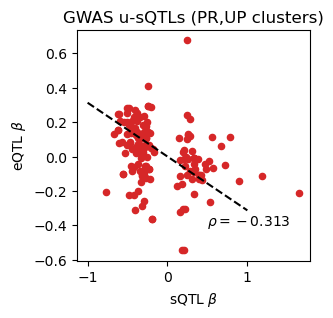

In [49]:
fig, ax = plt.subplots(figsize=(3, 3))
x = np.array(nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='UP') & (nom_df.PSI >= 0)].sQTL_beta)
y = np.array(nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='UP')  & (nom_df.PSI >= 0)].eQTL_beta)
plt.scatter(x, y, c='tab:red', s=20)

plt.plot([-1, 1], np.array([-1, 1])*(-0.31301181841836356), linestyle='--', c='black')
plt.text(0.5, -0.4, r'$\rho=-0.313$')
ax.set_xlabel(r'sQTL $\beta$')
ax.set_ylabel(r'eQTL $\beta$')
ax.set_title('GWAS u-sQTLs (PR,UP clusters)')
# ax.set_xlim([-1.5, 1.5])
# ax.set_ylim([-1.5, 1.5])

SignificanceResult(statistic=-0.37031148441037115, pvalue=2.4585765789828094e-06)


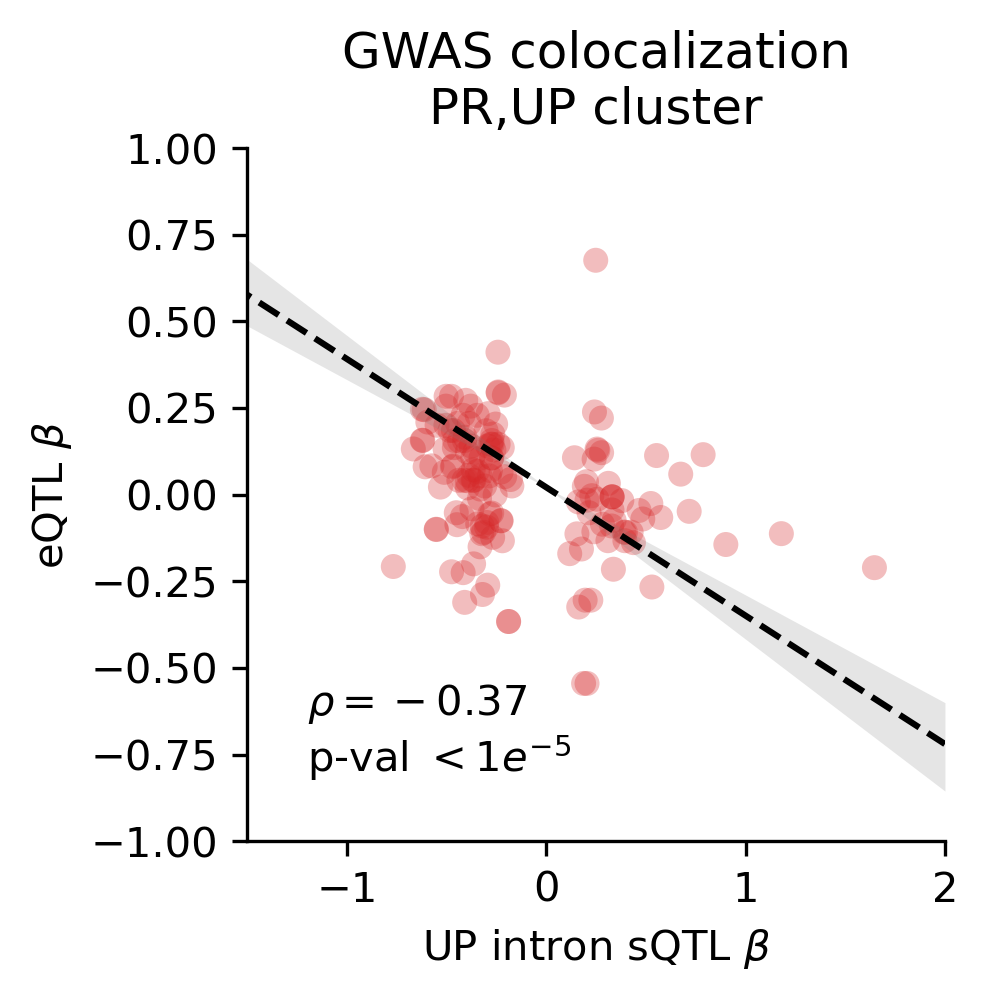

In [78]:
x = np.array(nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='UP') & (nom_df.PSI >= 0)].sQTL_beta)
y = np.array(nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='UP')  & (nom_df.PSI >= 0)].eQTL_beta)
rho_list = []
for i in range(100):
    idx = np.random.choice(np.arange(len(x)), 100, replace=False)
    rho_list.append(spearmanr(x[idx], y[idx])[0])

print(spearmanr(x, y))
    
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
plt.scatter(x, y, facecolor='tab:red', edgecolor='none', alpha=0.3, rasterized=True)


slope = spearmanr(x, y)[0]
intercept = np.mean(y)
slope_90 = np.quantile(rho_list, 0.9)
slope_10 = np.quantile(rho_list, 0.1)

# Plot confidence intervals (optional)

x = np.linspace(-2, 2, 100)

ax.plot(x, slope * x + intercept, color='black', linestyle='--')


ax.fill_between(x,( slope_90 * np.array(x)) + intercept, 
                (slope_10 * x) + intercept, 
                 color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.set_xlim([-1.5, 2])

ax.set_ylim([-1, 1])

ax.spines[['top', 'right']].set_visible(False)

ax.text(-1.2, -0.8, r'$\rho = -0.37$' + '\np-val $< 1e^{-5}$')
ax.set_xlabel(r'UP intron sQTL $\beta$')
ax.set_ylabel(r'eQTL $\beta$')
ax.set_title('GWAS colocalization\nPR,UP cluster')
plt.savefig('../code/plots/fig4_colocs_sc.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_colocs_sc.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_colocs_sc.svg', dpi=300, bbox_inches='tight')

In [35]:
pearsonr(x, y)

PearsonRResult(statistic=np.float64(-0.31301181841836356), pvalue=np.float64(8.16682474772931e-05))

SignificanceResult(statistic=0.36193758932316267, pvalue=8.810191126677442e-05)


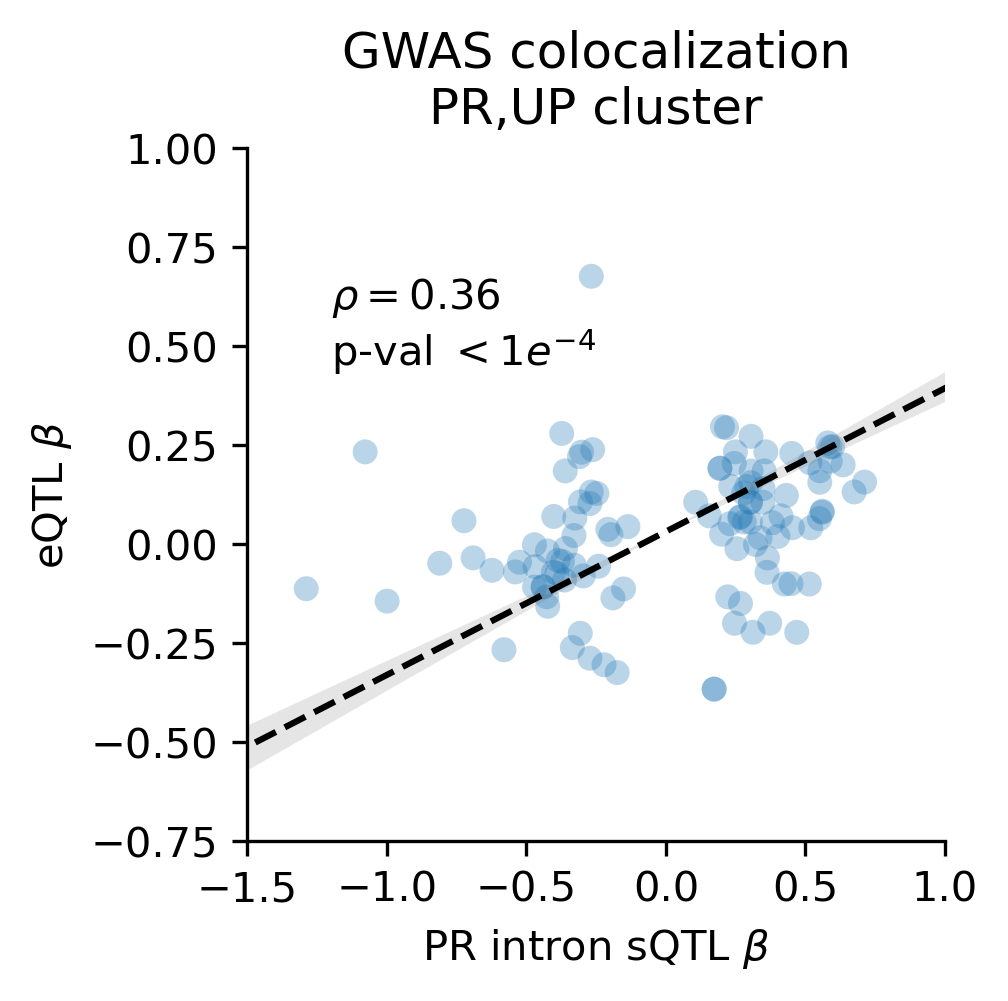

In [79]:
x = np.array(nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='PR') & (nom_df.PSI >= 0)].sQTL_beta)
y = np.array(nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='PR')  & (nom_df.PSI >= 0)].eQTL_beta)
rho_list = []
for i in range(100):
    idx = np.random.choice(np.arange(len(x)), 100, replace=False)
    rho_list.append(spearmanr(x[idx], y[idx])[0])

print(spearmanr(x, y))
    
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
plt.scatter(x, y, facecolor='tab:blue', edgecolor='none', alpha=0.3, rasterized=True)


slope = spearmanr(x, y)[0]
intercept = np.mean(y)
slope_90 = np.quantile(rho_list, 0.9)
slope_10 = np.quantile(rho_list, 0.1)

# Plot confidence intervals (optional)

x = np.linspace(-2, 2, 100)

ax.plot(x, slope * x + intercept, color='black', linestyle='--')


ax.fill_between(x,( slope_90 * np.array(x)) + intercept, 
                (slope_10 * x) + intercept, 
                 color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.set_xlim([-1.5, 1])

ax.set_ylim([-0.75, 1])

ax.spines[['top', 'right']].set_visible(False)

ax.text(-1.2, 0.45, r'$\rho = 0.36$' + '\np-val $< 1e^{-4}$')
ax.set_xlabel(r'PR intron sQTL $\beta$')
ax.set_ylabel(r'eQTL $\beta$')
ax.set_title('GWAS colocalization\nPR,UP cluster')
# plt.savefig('../code/plots/fig4B1.png', dpi=300, bbox_inches='tight')
# plt.savefig('../code/plots/fig4B1.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('../code/plots/fig4B1.svg', dpi=300, bbox_inches='tight')

plt.savefig('../code/plots/fig4_colocs_sc2.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_colocs_sc2.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_colocs_sc2.svg', dpi=300, bbox_inches='tight')

In [37]:
pearsonr(x, y)

PearsonRResult(statistic=np.float64(0.28205758473441966), pvalue=np.float64(0.002587181812465168))

In [38]:
nom_df['chrom'] = nom_df.intron.apply(lambda x: x.split(':')[0])
nom_df['start'] = nom_df.intron.apply(lambda x: int(x.split(':')[1]))
nom_df['end'] = nom_df.intron.apply(lambda x: int(x.split(':')[2]))
nom_df['cluster'] = nom_df.intron.apply(lambda x: x.split(':')[3])
nom_df['gwas_trait'] = nom_df.intron.apply(lambda x: x.split('_N_N_')[1])
nom_df['gwas_loci'] = nom_df.intron.apply(lambda x: x.split(':')[-1])

In [261]:
juncs_to_keep = nom_df.loc[
    (nom_df.distance <= 100) & (nom_df.var_id == 'chr12_57695630_A_T_b38') & (nom_df.gene == 'ENSG00000135506'),
          ['chrom', 'start', 'end']].drop_duplicates()

juncs_to_keep.columns = ['#Chrom', 'start', 'end']
juncs_to_keep.to_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_sashimi_plots/input/clusters/chr12_57713053_N_N_IMSGC2019.bed',
                    sep='\t', index=False, header=True)

In [289]:
juncs_to_keep

,#Chrom,start,end
269,chr12,57694926,57695542
270,chr12,57694926,57695779
303,chr12,57695677,57695779


In [283]:
nom_df.loc[(nom_df.distance <= 100) & (nom_df.itype=='UP') & (nom_df.PSI >= 0.1)]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end
133,chr11:614037:614475:clu_21681_-:UP:chr11_57875...,ENSG00000185507,chr11_614318_T_C_b38,0,157,-0.209540,3.369030e-07,0.051806,5.398490e-02,clu_21681_-,UP,Artery-Tibial,0.376014,chr11,614037,614475
140,chr11:614037:614475:clu_21884_-:UP:chr11_57875...,ENSG00000185507,chr11_614318_T_C_b38,0,157,-0.389297,1.234810e-17,0.055899,7.470950e-02,clu_21884_-,UP,Colon-Transverse,0.273330,chr11,614037,614475
165,chr11:614037:614475:clu_21453_-:UP:chr11_57875...,ENSG00000185507,chr11_614318_T_C_b38,0,157,-0.435814,1.138990e-14,0.155239,4.549520e-05,clu_21453_-,UP,Stomach,0.268905,chr11,614037,614475
209,chr11:70420510:70422508:clu_20640_+:UP:chr11_7...,ENSG00000085733,chr11_70420920_A_G_b38,0,410,-0.281030,1.351080e-09,0.069587,5.115330e-02,clu_20640_+,UP,Esophagus-GastroesophagealJunction,0.247662,chr11,70420510,70422508
215,chr11:70422592:70422939:clu_21229_+:UP:chr11_7...,ENSG00000085733,chr11_70422804_C_T_b38,0,135,-0.271864,1.572710e-11,0.145604,2.060170e-06,clu_21229_+,UP,Esophagus-Muscularis,0.175069,chr11,70422592,70422939
694,chr15:40288642:40289271:clu_29166_-:UP:chr15_4...,ENSG00000137841,chr15_40288963_C_A_b38,0,308,-0.220781,2.964690e-06,-0.133029,5.431500e-07,clu_29166_-,UP,Thyroid,0.133663,chr15,40288642,40289271
797,chr15:68335814:68339499:clu_29124_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.378467,1.236580e-07,-0.017169,7.300140e-01,clu_29124_-,UP,Adipose-Subcutaneous,0.133663,chr15,68335814,68339499
799,chr15:68335814:68339499:clu_28898_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.339738,3.107650e-07,-0.073803,2.008080e-01,clu_28898_-,UP,Adipose-Visceral_Omentum,0.133663,chr15,68335814,68339499
807,chr15:68335814:68339499:clu_28369_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.329131,4.871640e-07,-0.044205,2.970690e-01,clu_28369_-,UP,Esophagus-Muscularis,0.147572,chr15,68335814,68339499
809,chr15:68335814:68339499:clu_27785_-:UP:chr15_6...,ENSG00000137809,chr15_68335825_C_T_b38,0,11,0.573819,1.945940e-12,-0.065886,3.893950e-01,clu_27785_-,UP,Heart-AtrialAppendage,0.129913,chr15,68335814,68339499


In [287]:
nom_df.loc[1768].intron

'chr1:93156483:93158814:clu_2837_-:UP:chr1_93282126_N_N_age_when_finished_full-time_education'

In [272]:
nom_df.loc[1290].intron

'chr17:81511803:81511902:clu_32738_-:UP:chr17_81183249_N_N_GCST004133'

In [266]:
nom_df.loc[(nom_df.distance <= 100) & (nom_df.itype=='UP')].sort_values('PSI').intron.iloc[-1]

'chr17:44176940:44177608:clu_29318_+:UP:chr17_44114525_N_N_bipolar_disorder'

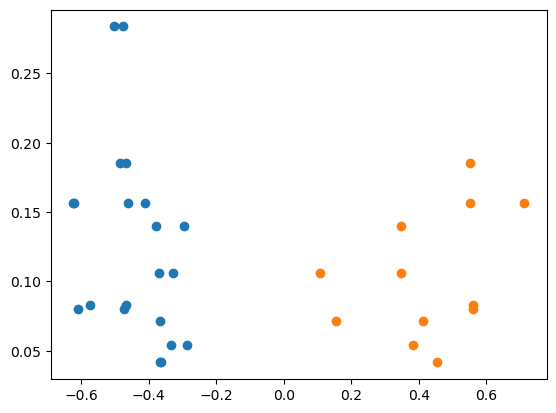

In [250]:
plt.scatter(nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='UP') & (nom_df.PSI >= 0) & (nom_df.var_id == 'chr12_57695630_A_T_b38') & (nom_df.gene == 'ENSG00000135506')].sQTL_beta,
nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='UP')  & (nom_df.PSI >= 0) & (nom_df.var_id == 'chr12_57695630_A_T_b38') & (nom_df.gene == 'ENSG00000135506')].eQTL_beta)

plt.scatter(nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='PR') & (nom_df.PSI >= 0) & (nom_df.var_id == 'chr12_57695630_A_T_b38') & (nom_df.gene == 'ENSG00000135506')].sQTL_beta,
nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='PR')  & (nom_df.PSI >= 0) & (nom_df.var_id == 'chr12_57695630_A_T_b38') & (nom_df.gene == 'ENSG00000135506')].eQTL_beta)

In [227]:
nom_df.loc[(nom_df.var_id == 'chr12_57695630_A_T_b38') & (nom_df.gene == 'ENSG00000135506')]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI
269,chr12:57694926:57695542:clu_24025_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,88,88,-0.367434,2.751420e-19,0.071563,1.592570e-02,clu_24025_+,UP,Adipose-Subcutaneous,0.009121
270,chr12:57694926:57695779:clu_24025_+:PR:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,0,149,0.412180,1.259130e-20,0.071563,1.592570e-02,clu_24025_+,PR,Adipose-Subcutaneous,1.000000
271,chr12:57696038:57715759:clu_24027_+:PR:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,408,408,0.155224,1.092480e-06,0.071563,1.592570e-02,clu_24027_+,PR,Adipose-Subcutaneous,0.009780
301,chr12:57694926:57695542:clu_21536_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,88,88,-0.363597,4.725620e-08,0.041605,3.036540e-01,clu_21536_+,UP,Brain-CerebellarHemisphere,0.014973
302,chr12:57694926:57695779:clu_21536_+:PR:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,0,149,0.453241,1.110800e-09,0.041605,3.036540e-01,clu_21536_+,PR,Brain-CerebellarHemisphere,1.000000
303,chr12:57695677:57695779:clu_21536_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,47,47,-0.367895,5.296530e-08,0.041605,3.036540e-01,clu_21536_+,UP,Brain-CerebellarHemisphere,0.012157
341,chr12:57694926:57695542:clu_19636_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,88,88,-0.620360,2.068250e-12,0.156767,2.945830e-03,clu_19636_+,UP,Cells-EBV-transformedlymphocytes,0.017566
342,chr12:57694926:57695779:clu_19636_+:PR:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,0,149,0.711907,1.230310e-13,0.156767,2.945830e-03,clu_19636_+,PR,Cells-EBV-transformedlymphocytes,0.998027
343,chr12:57695677:57695779:clu_19636_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,47,47,-0.623275,3.120300e-13,0.156767,2.945830e-03,clu_19636_+,UP,Cells-EBV-transformedlymphocytes,0.015642
344,chr12:57694926:57695542:clu_23648_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,88,88,-0.471758,1.435690e-18,0.080386,2.341000e-03,clu_23648_+,UP,Colon-Transverse,0.016207


In [42]:
pearsonr(nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='UP') & (nom_df.PSI >= 0.0)].sQTL_beta,
nom_df.loc[(nom_df.distance_abs <= 1000) & (nom_df.itype=='UP')  & (nom_df.PSI >= 0.0)].eQTL_beta)

PearsonRResult(statistic=np.float64(-0.31301181841836356), pvalue=np.float64(8.16682474772931e-05))

In [205]:
from scipy.stats import pearsonr, spearmanr
sqtls = []
eqtls = []
for gene, df in nom_df.loc[(nom_df.distance <= 1000) & (nom_df.itype=='UP')& (nom_df.PSI >= 0.01)].groupby('gene'):
    best = df.sort_values('sQTL_pval').iloc[0]
    sqtls.append(best.sQTL_beta)
    eqtls.append(best.eQTL_beta)
    
pearsonr(sqtls, eqtls)

PearsonRResult(statistic=np.float64(-0.018693497666381252), pvalue=np.float64(0.9029928037705477))

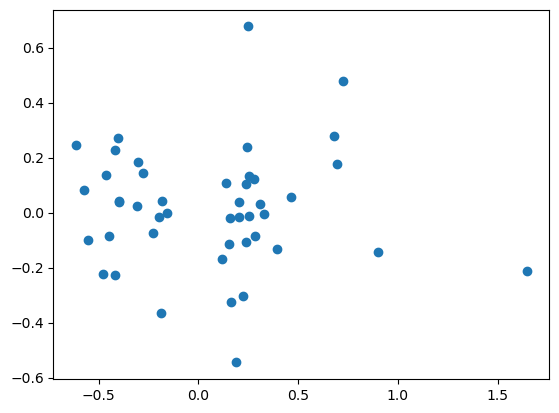

In [206]:
plt.scatter(sqtls, eqtls)

In [175]:
spearmanr(nom_df.loc[(nom_df.distance <= 100) & (nom_df.itype=='UP') & (nom_df.PSI >= 0.01)].sQTL_beta,
nom_df.loc[(nom_df.distance <= 100) & (nom_df.itype=='UP')  & (nom_df.PSI >= 0.01)].eQTL_beta)

SignificanceResult(statistic=np.float64(-0.678034415508103), pvalue=np.float64(2.6586651657787957e-09))

In [312]:
nom_df.gwas_trait.unique()

array(['age_when_finished_full-time_education',
       'Visceral_adipose_tissue_measurement', 'coronary_artery_disease',
       'Hypothyroidism', 'bipolar_disorder',
       'Chronic_obstructive_pulmonary_disease', 'GCST004988',
       'schizophrenia', 'heart_failure', 'basal_cell_carcinoma',
       'myocardial_infarction', 'GCST004131', 'GCST007800',
       'Dupuytrens_disease', 'atrial_fibrillation', 'IMSGC2019',
       'GCST004132', 'GCST004133', 'Atopic_eczema'], dtype=object)

In [313]:
nom_df.loc[(nom_df.distance <= 100)  & (nom_df.itype=='UP') & (nom_df.PSI >= 0.01) & (nom_df.gwas_trait == 'coronary_artery_disease') & (((nom_df.sQTL_beta > 0) & (nom_df.eQTL_beta < 0)) | ((nom_df.sQTL_beta < 0) & (nom_df.eQTL_beta > 0)))]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait
678,chr14:75135886:75139073:clu_30689_-:UP:chr14_7...,ENSG00000170348,chr14_75136131_A_T_b38,0,245,0.153227,4.203090e-05,-0.113077,8.210830e-07,clu_30689_-,UP,Testis,0.026357,chr14,75135886,75139073,coronary_artery_disease
988,chr16:72017106:72020401:clu_26029_+:UP:chr16_7...,ENSG00000102967,chr16_72017470_A_G_b38,0,364,-0.396940,2.441060e-08,0.040264,3.799990e-01,clu_26029_+,UP,Liver,0.016295,chr16,72017106,72020401,coronary_artery_disease


In [315]:
nom_df.loc[nom_df.gene == 'ENSG00000102967']

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait
985,chr16:72020498:72021123:clu_29651_+:UP:chr16_7...,ENSG00000102967,chr16_72000965_T_C_b38,19533,19533,-0.212703,1.512060e-06,0.388951,1.031880e-30,clu_29651_+,UP,Artery-Tibial,0.035956,chr16,72020498,72021123,coronary_artery_disease
986,chr16:72017106:72020401:clu_29016_+:UP:chr16_7...,ENSG00000102967,chr16_72017470_A_G_b38,0,364,-0.324088,1.205960e-07,-0.112675,8.462330e-03,clu_29016_+,UP,Heart-AtrialAppendage,0.024880,chr16,72017106,72020401,coronary_artery_disease
987,chr16:72020498:72021123:clu_29016_+:UP:chr16_7...,ENSG00000102967,chr16_72017470_A_G_b38,3028,3028,-0.278868,1.327640e-06,-0.112675,8.462330e-03,clu_29016_+,UP,Heart-AtrialAppendage,0.022548,chr16,72020498,72021123,coronary_artery_disease
988,chr16:72017106:72020401:clu_26029_+:UP:chr16_7...,ENSG00000102967,chr16_72017470_A_G_b38,0,364,-0.396940,2.441060e-08,0.040264,3.799990e-01,clu_26029_+,UP,Liver,0.016295,chr16,72017106,72020401,coronary_artery_disease
989,chr16:72020498:72021123:clu_26029_+:UP:chr16_7...,ENSG00000102967,chr16_72017470_A_G_b38,3028,3028,-0.354604,1.448110e-06,0.040264,3.799990e-01,clu_26029_+,UP,Liver,0.015066,chr16,72020498,72021123,coronary_artery_disease


In [ ]:
chr17   44176940        44177608
chr17   44177230        44177608

In [ ]:
juncs_to_keep = nom_df.loc[
    (nom_df.distance <= 100) & (nom_df.var_id == 'chr12_57695630_A_T_b38') & (nom_df.gene == 'ENSG00000135506'),
          ['chrom', 'start', 'end']].drop_duplicates()

juncs_to_keep.columns = ['#Chrom', 'start', 'end']
juncs_to_keep.to_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_sashimi_plots/input/clusters/chr12_57713053_N_N_IMSGC2019.bed',
                    sep='\t', index=False, header=True)

In [97]:
query = tabix_PSI('Artery-Tibial', 'chr16:1315726:1319701:clu_28820_+:UP:chr16_1194887_N_N_age_when_finished_full-time_education')

In [102]:
np.quantile(query, 0.9)

np.float64(0.01434533896921514)

In [94]:
q

['chr16',
 '1315726',
 '1319701',
 'chr16:1315726:1319701:clu_28820_+:UP',
 '.',
 '+',
 '0.058653149891383066',
 '4.1839253587715995e-05',
 '0.013732406424437519',
 '0.010360290706664605',
 '0.003659287706967139',
 '2.631509697113234e-05',
 '0.012101156976884617',
 '0.01416911063213314',
 '0.007757532022370557',
 '0.00290221545357892',
 '0.0069307954898106955',
 '2.392287265854884e-05',
 '0.02319337067728346',
 '0.006203512237276627',
 '0.002348782586451478',
 '0.003607014035213028',
 '0.006633444440777531',
 '0.0024937655860349127',
 '0.0061092368013130295',
 '0.005126643317598092',
 '0.005234238691700736',
 '0.017156946679908223',
 '0.006633444440777531',
 '0.0144467681065359',
 '0.003023861561031107',
 '1.8415867111102927e-05',
 '0.036135879571134615',
 '0.016026239300285326',
 '0.004516752432529606',
 '0.003176000754693249',
 '4.4640864247131826e-05',
 '0.0036460777589256707',
 '0.003355370253479951',
 '0.013592759567472289',
 '0.005493075437322776',
 '0.0031660449515689163',
 '0.0

In [ ]:
get_nominal_splicing(trait, gwas_loci, var_id)

In [28]:
from scipy.stats import spearmanr
spearmanr(nom_df.loc[(nom_df.distance <= 1e6) & (nom_df.itype=='UP')].sQTL_beta,
nom_df.loc[(nom_df.distance <= 1e6) & (nom_df.itype=='UP')].eQTL_beta)

SignificanceResult(statistic=np.float64(-0.08900755394797405), pvalue=np.float64(0.0021446889727832546))

In [249]:
nom_df = pd.DataFrame(nom_list, columns = ['sqtl_beta', 'eqtl_beta', 'gene', 'sqtl_pval', 'eqtl_pval', 'clu', 
                                           'itype', 'tissue'])

In [250]:
nom_up = nom_df.loc[(nom_df.itype == 'UP')].groupby('gene')[['sqtl_beta', 'eqtl_beta']].mean()

In [251]:
nom_df.loc[(nom_df.itype == 'UP') ]

,sqtl_beta,eqtl_beta,gene,sqtl_pval,eqtl_pval,clu,itype,tissue
0,-0.250987,0.229712,ENSG00000175470,7.948880e-09,8.585120e-10,clu_20179_+,UP,Adipose-Subcutaneous
1,-0.191042,0.151185,ENSG00000175470,3.898810e-07,8.278650e-06,clu_19365_+,UP,Muscle-Skeletal
3,-0.220831,0.361533,ENSG00000175470,3.533850e-07,2.212810e-17,clu_20249_+,UP,Skin-NotSunExposed_Suprapubic
4,-0.130256,-0.666193,ENSG00000149292,1.070810e-03,2.327860e-71,clu_22000_+,UP,Adipose-Subcutaneous
8,-0.302199,-0.571314,ENSG00000149292,2.272230e-10,3.150080e-48,clu_21877_+,UP,Adipose-Visceral_Omentum
...,...,...,...,...,...,...,...,...
145,-0.242090,0.145604,ENSG00000085733,1.742350e-06,2.060170e-06,clu_21229_+,UP,Esophagus-Muscularis
146,0.202384,-0.019791,ENSG00000177225,9.210860e-04,5.089500e-01,clu_21103_-,UP,Esophagus-GastroesophagealJunction
147,-0.302786,0.184477,ENSG00000177595,6.481420e-06,9.285970e-06,clu_21995_-,UP,Pituitary
149,-0.165495,0.045027,ENSG00000184014,1.817610e-04,1.481720e-01,clu_21843_-,UP,Artery-Tibial


# Check cluster type as well

In [252]:
up_sqtl_beta = []
up_eqtl_beta = []
for gene, df in nom_df.loc[(nom_df.itype == 'UP')].groupby('gene'):
    up_sqtl_beta.append(df.sort_values('sqtl_pval').iloc[0].sqtl_beta)
    up_eqtl_beta.append(df.sort_values('sqtl_pval').iloc[0].eqtl_beta)

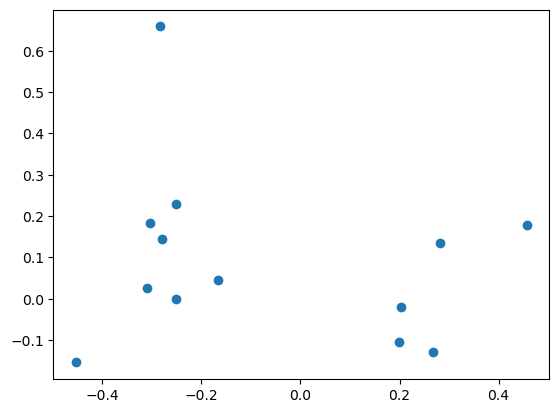

In [253]:
plt.scatter(up_sqtl_beta, up_eqtl_beta)

In [255]:
pearsonr(up_sqtl_beta, up_eqtl_beta)

PearsonRResult(statistic=np.float64(-0.1903489361433477), pvalue=np.float64(0.5333522499448674))

In [178]:
nom_df.loc[(nom_df.itype == 'UP') & (nom_df.sqtl_beta > 0) & (nom_df.eqtl_beta > 0) & (nom_df.gene == 'ENSG00000164535')]

,sqtl_beta,eqtl_beta,gene,sqtl_pval,eqtl_pval,clu,itype
730,0.395909,0.856348,ENSG00000164535,5.355250e-22,6.662460e-83,clu_15576_-,UP
734,0.595595,0.613650,ENSG00000164535,1.694420e-24,1.442990e-34,clu_14851_-,UP
736,0.542668,0.503334,ENSG00000164535,4.220400e-13,2.177060e-16,clu_14511_-,UP
740,0.634879,0.275497,ENSG00000164535,2.797470e-10,1.030760e-04,clu_13805_-,UP
748,0.478296,0.179252,ENSG00000164535,1.222060e-09,2.051980e-04,clu_13967_-,UP
750,0.484805,0.275703,ENSG00000164535,6.976270e-07,4.971690e-04,clu_13996_-,UP
760,0.687767,0.588521,ENSG00000164535,3.457960e-25,1.864400e-27,clu_14766_-,UP
766,0.496120,0.541829,ENSG00000164535,3.267810e-19,1.588220e-26,clu_14924_-,UP
768,0.486266,0.299037,ENSG00000164535,5.413100e-20,3.545320e-13,clu_14277_-,UP
774,0.602449,0.629906,ENSG00000164535,6.849110e-38,6.352960e-43,clu_15968_-,UP


In [179]:
nom_df.loc[(nom_df.itype == 'UP') & (nom_df.sqtl_beta > 0) & (nom_df.eqtl_beta > 0) & (nom_df.clu == 'clu_15576_-')]

,sqtl_beta,eqtl_beta,gene,sqtl_pval,eqtl_pval,clu,itype
730,0.395909,0.856348,ENSG00000164535,5.355250e-22,6.662460e-83,clu_15576_-,UP


In [213]:
hyprcoloc.loc[hyprcoloc.UP_colocs & hyprcoloc.expr_colocs].iloc[0]

iteration                                                                     1
traits                        AdrenalGland.leafcutter_N_N_chr10:100983817:10...
posterior_prob                                                           0.8228
regional_prob                                                            0.9882
candidate_snp                                           chr10_100972002_T_A_b38
posterior_explained_by_snp                                               0.1476
dropped_trait                                                               NaN
gwas_trait                                  Visceral_adipose_tissue_measurement
gwas_colocs                                                               False
UP_colocs                                                                  True
expr_colocs                                                                True
lfc_colocs                                                                 True
lfc_other_colocs                        

In [236]:
get_nominal_splicing('AdrenalGland.leafcutter_N_N_chr10:100984074:100987089:clu_19100_-:UP:ENSG00000055950.16', 
                     'chr10_100705496_N_N_Visceral_adipose_tissue_measurement', 'chr10_100972002_T_A_b38')

AdrenalGland
chr10


(                                                  phe_id phe_chr   phe_from  \
 17815  chr10:100984074:100987089:clu_19100_-:UP:chr10...   chr10  100205497   
 
           phe_to phe_strd n_var_in_cis dist_phe_var                   var_id  \
 17815  101205496        -         2048            0  chr10_100972002_T_A_b38   
 
       var_chr   var_from     var_to     nom_pval r_squared      slope  \
 17815   chr10  100972002  100972002  2.35057e-12  0.192084  -0.537622   
 
         slope_se best_hit  
 17815  0.0725451        0  ,
                                                   phe_id phe_chr   phe_from  \
 23744  ENSG00000055950.16:chr10_100705496_N_N_Viscera...   chr10  100205497   
 
           phe_to phe_strd n_var_in_cis dist_phe_var                   var_id  \
 23744  101205496        -         2048            0  chr10_100972002_T_A_b38   
 
       var_chr   var_from     var_to     nom_pval  r_squared     slope  \
 23744   chr10  100972002  100972002  0.000426126  0.0524316  0.1

In [231]:
expression_tbx = tabix.open(f'../code/results/coloc/qtls/AdrenalGland/expression.NominalPass/chr10.txt.tabix.gz')
df_expression = tabix_nominal_to_df(expression_tbx, 'chr10', int(100705496-5e5), int(100705496+5e5))
expression_nom = df_expression.loc[
        (df_expression.phe_id.apply(lambda x: ('ENSG00000055950' in x ) and ('chr10_100705496_N_N_Visceral_adipose_tissue_measurement' in x))) & (df_expression.var_id == 'chr10_100972002_T_A_b38')]
    

'ENSG00000248746'

In [220]:
expression_nom = df_expression.loc[
        (df_expression.phe_id.apply(lambda x: (gene in x ) and (gwas_loci in x)))]

In [225]:
expression_tbx = tabix.open(f'../code/results/coloc/qtls/AdrenalGland/expression.NominalPass/chr10.txt.tabix.gz')
df_expression = tabix_nominal_to_df(expression_tbx, 'chr10', int(100705496-5e5), int(100705496+5e5))

In [233]:
expression_nom

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
23744,ENSG00000055950.16:chr10_100705496_N_N_Viscera...,chr10,100205497,101205496,-,2048,0,chr10_100972002_T_A_b38,chr10,100972002,100972002,0.000426126,0.0524316,0.189913,0.05312,0


In [105]:
from scipy.stats import spearmanr, pearsonr
spearmanr(nom_df.sqtl_beta, nom_df.eqtl_beta)

SignificanceResult(statistic=np.float64(-0.056288772419394), pvalue=np.float64(0.10964066128351675))

In [108]:
nom_df['gap'] = (nom_df.eqtl_beta - nom_df.sqtl_beta).abs()

In [110]:
for gene, nom in nom_df.groupby('gene'):
    break

'chr9:108936437:108939195:clu_18674_+:PR:chr9_109129674_N_N_age_when_finished_full-time_education'

In [112]:
aver[0]

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
11131,chr9:108936437:108939195:clu_18674_+:PR:chr9_1...,chr9,108629675,109629674,+,2843,0,chr9_108996310_A_G_b38,chr9,108996310,108996310,8.51718e-05,0.0266547,-0.186993,0.0472469,0


In [79]:
splicing, expression = pair
tissue, intron, n = splicing.split('.')
intron = intron.split('_N_N_')[1]
intron = ':'.join(intron.split(':')[:-1])
gene = expression.split('_N_N_')[1]

chrom_pos = gwas_loci.split('_N_N_')[0]
chrom, pos = chrom_pos.split('_')
pos = int(pos)
splicing_phe_id = intron + ':' + gwas_loci

splicing_tbx = tabix.open(f'../code/results/coloc/qtls/{tissue}/leafcutter.NominalPass/{chrom}.txt.tabix.gz')
start = int(pos-5e5)
end = int(pos+5e5)
df_splicing = tabix_nominal_to_df(splicing_tbx, chrom, start, end)
splicing_nom = df_splicing.loc[(df_splicing.phe_id == splicing_phe_id) & (df_splicing.var_id == var_id)]

expression_tbx = tabix.open(f'../code/results/coloc/qtls/{tissue}/expression.NominalPass/{chrom}.txt.tabix.gz')
df_expression = tabix_nominal_to_df(expression_tbx, chrom, start, end)
expression_nom = df_expression.loc[
    (df_expression.phe_id.apply(lambda x: (gene in x ) and (gwas_loci in x))) & (df_expression.var_id == var_id)]


In [82]:
splicing_phe_id

'chr11:113363927:113364834:clu_20243_+:PR:chr11_113363957_N_N_Visceral_adipose_tissue_measurement'

In [84]:
df_splicing.loc[df_splicing.phe_id == splicing_phe_id]

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
4,chr11:113363927:113364834:clu_20243_+:PR:chr11...,chr11,112863958,113863957,+,2317,0,chr11_112865874_T_C_b38,chr11,112865874,112865874,0.46031,0.00236223,-0.0676236,0.091436,0
14,chr11:113363927:113364834:clu_20243_+:PR:chr11...,chr11,112863958,113863957,+,2317,0,chr11_112867716_A_G_b38,chr11,112867716,112867716,0.886817,8.78855e-05,-0.0104181,0.073115,0
24,chr11:113363927:113364834:clu_20243_+:PR:chr11...,chr11,112863958,113863957,+,2317,0,chr11_112868243_C_T_b38,chr11,112868243,112868243,0.643175,0.000930646,0.0338515,0.0729757,0
34,chr11:113363927:113364834:clu_20243_+:PR:chr11...,chr11,112863958,113863957,+,2317,0,chr11_112868641_A_G_b38,chr11,112868641,112868641,0.804575,0.000265569,-0.0181741,0.0733672,0
44,chr11:113363927:113364834:clu_20243_+:PR:chr11...,chr11,112863958,113863957,+,2317,0,chr11_112871375_A_G_b38,chr11,112871375,112871375,0.241576,0.00593188,-0.102674,0.0874513,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42398,chr11:113363927:113364834:clu_20243_+:PR:chr11...,chr11,112863958,113863957,+,2317,0,chr11_113861860_G_A_b38,chr11,113861860,113861860,0.215783,0.00662521,-0.176336,0.142067,0
42418,chr11:113363927:113364834:clu_20243_+:PR:chr11...,chr11,112863958,113863957,+,2317,0,chr11_113862025_T_A_b38,chr11,113862025,113862025,0.215783,0.00662521,-0.176336,0.142067,0
42438,chr11:113363927:113364834:clu_20243_+:PR:chr11...,chr11,112863958,113863957,+,2317,0,chr11_113862106_C_G_b38,chr11,113862106,113862106,0.141952,0.0093128,-0.142035,0.0963868,0
42458,chr11:113363927:113364834:clu_20243_+:PR:chr11...,chr11,112863958,113863957,+,2317,0,chr11_113862389_G_T_b38,chr11,113862389,113862389,0.215747,0.00662623,-0.0891861,0.0718479,0


In [11]:
gwas_pct_list = []
gwas_pct_all_list = []
trait_list = []
for trait, df in nom_df.groupby('gwas_trait'): #.loc[nom_df.itype != 'PR'].groupby('gwas_trait'):
    gwas_pct = pd.DataFrame(
        100*df.groupby(['tissue', 'gwas_loci']).tissue.value_counts().reset_index().tissue.value_counts()/(leadSNPs.loc[leadSNPs.gwas_trait == trait].shape[0])
    )
    gwas_pct.columns = [trait]
    gwas_pct_list.append(gwas_pct)
    
    gwas_pct_all = len(df.gwas_loci.unique())/(leadSNPs.loc[leadSNPs.gwas_trait == trait].shape[0])
    gwas_pct_all_list.append(gwas_pct_all)
    
    trait_list.append(trait)

In [12]:
nom_df.loc[nom_df.gwas_trait == 'IMSGC2019'].groupby(['tissue', 'gwas_loci', 'var_id']).tissue.value_counts().reset_index().tissue.value_counts()

tissue
Esophagus-Muscularis                   5
Brain-Nucleusaccumbens_basalganglia    3
Brain-Cortex                           3
Skin-NotSunExposed_Suprapubic          3
Prostate                               3
Colon-Transverse                       3
Thyroid                                3
Testis                                 3
Uterus                                 3
Muscle-Skeletal                        3
Skin-SunExposed_Lowerleg               3
Cells-Culturedfibroblasts              3
Adipose-Visceral_Omentum               3
Heart-LeftVentricle                    3
Brain-Caudate_basalganglia             2
Adipose-Subcutaneous                   2
AdrenalGland                           2
Pituitary                              2
Nerve-Tibial                           2
Ovary                                  2
Brain-Putamen_basalganglia             2
Brain-CerebellarHemisphere             2
Brain-Cerebellum                       2
Brain-Hypothalamus                     2
Brain-Fro

In [13]:
len(df.gwas_loci.unique())

16

In [46]:
df.groupby('tissue').tissue.value_counts().max()

np.int64(13)

In [15]:
gwas_pct

,schizophrenia
tissue,
Testis,2.475248
Thyroid,1.485149
Esophagus-Muscularis,1.485149
Adipose-Subcutaneous,0.990099
Brain-CerebellarHemisphere,0.990099
Colon-Sigmoid,0.990099
Heart-AtrialAppendage,0.990099
Brain-Cerebellum,0.990099
Artery-Tibial,0.990099


In [225]:
gwas_pct_all_list

[0.014285714285714285,
 0.07175925925925926,
 0.0625,
 0.07801418439716312,
 0.061855670103092786,
 0.08064516129032258,
 0.07142857142857142,
 0.08256880733944955,
 0.07947019867549669,
 0.14473684210526316,
 0.08615384615384615,
 0.08469055374592833,
 0.036036036036036036,
 0.07446808510638298,
 0.16923076923076924,
 0.09502262443438914,
 0.09523809523809523,
 0.07142857142857142,
 0.07920792079207921]

In [16]:
gwas_pct_df = pd.concat(gwas_pct_list, axis=1).fillna(0)
gwas_pct_all_df = pd.DataFrame()
gwas_pct_all_df['trait'] = trait_list
gwas_pct_all_df['gwas_pct'] = gwas_pct_all_list

ordered_traits = list(gwas_pct_all_df.sort_values('gwas_pct', ascending=False).trait)

gwas_pct_all_df.index = gwas_pct_all_df.trait
gwas_pct_all_df.loc[ordered_traits]

,trait,gwas_pct
trait,,
bipolar_disorder,bipolar_disorder,0.169231
IMSGC2019,IMSGC2019,0.144737
heart_failure,heart_failure,0.095238
coronary_artery_disease,coronary_artery_disease,0.095023
Visceral_adipose_tissue_measurement,Visceral_adipose_tissue_measurement,0.086154
age_when_finished_full-time_education,age_when_finished_full-time_education,0.084691
GCST007800,GCST007800,0.082569
GCST004133,GCST004133,0.080645
Hypothyroidism,Hypothyroidism,0.079470


In [21]:
gwas_pct_df.mean(axis=1).mean()

np.float64(0.7497749687123756)

In [32]:
225/2897

0.07766655160510873

In [31]:
gwas_pct_df[ordered_traits]#.max(axis=1).max()

,bipolar_disorder,IMSGC2019,heart_failure,coronary_artery_disease,Visceral_adipose_tissue_measurement,age_when_finished_full-time_education,GCST007800,GCST004133,Hypothyroidism,schizophrenia,GCST004131,basal_cell_carcinoma,Chronic_obstructive_pulmonary_disease,myocardial_infarction,GCST004988,Dupuytrens_disease,GCST004132,atrial_fibrillation,Atopic_eczema
tissue,,,,,,,,,,,,,,,,,,,
Lung,3.076923,2.631579,0.000000,2.262443,1.538462,1.302932,3.669725,1.612903,0.662252,0.990099,1.41844,0.00000,0.462963,1.190476,1.785714,1.5625,1.030928,0.000000,1.428571
Skin-SunExposed_Lowerleg,3.076923,3.947368,0.000000,3.167421,1.230769,0.651466,1.834862,0.000000,2.649007,0.000000,1.41844,0.00000,0.694444,1.190476,1.190476,1.5625,2.061856,0.000000,1.428571
Testis,0.000000,3.947368,2.380952,3.167421,2.153846,2.605863,2.752294,1.612903,0.000000,2.475248,1.41844,1.06383,1.851852,1.190476,1.190476,1.5625,1.030928,0.900901,0.000000
Adipose-Subcutaneous,3.076923,2.631579,0.000000,2.714932,0.923077,2.280130,4.587156,3.225806,1.986755,0.990099,0.70922,1.06383,1.388889,1.190476,1.190476,1.5625,1.030928,1.801802,0.000000
Esophagus-GastroesophagealJunction,0.000000,2.631579,0.000000,1.809955,1.230769,0.977199,2.752294,0.000000,0.662252,0.000000,0.00000,1.06383,1.388889,0.000000,1.190476,0.0000,0.000000,0.000000,0.000000
Artery-Tibial,3.076923,2.631579,0.000000,2.714932,0.307692,1.954397,3.669725,1.612903,1.986755,0.990099,0.70922,0.00000,1.388889,0.000000,0.595238,1.5625,0.000000,0.000000,0.000000
Colon-Sigmoid,1.538462,1.315789,0.000000,1.357466,0.615385,0.977199,2.752294,0.000000,0.662252,0.990099,0.70922,0.00000,1.157407,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000
Pituitary,1.538462,2.631579,0.000000,1.357466,0.615385,0.651466,1.834862,1.612903,1.324503,0.495050,1.41844,0.00000,1.157407,0.000000,0.595238,0.0000,0.000000,0.000000,0.000000
Prostate,0.000000,3.947368,0.000000,1.809955,0.307692,0.000000,1.834862,0.000000,0.662252,0.495050,0.00000,0.00000,1.157407,0.000000,0.000000,1.5625,0.000000,0.000000,0.000000


In [26]:
(100*gwas_pct_all_df.gwas_pct.median())

np.float64(7.920792079207921)

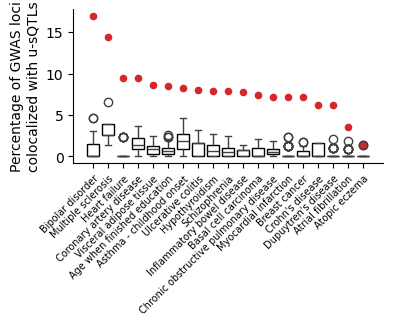

In [51]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.boxplot(data=gwas_pct_df[ordered_traits], ax=ax, boxprops=dict(facecolor='white', edgecolor='black'))
ax.scatter(range(19), list(100*gwas_pct_all_df.loc[ordered_traits].gwas_pct), c='tab:red', s=20)

xlabels = [#'Rheumatoid arthritis', 
           'Bipolar disorder', 'Multiple sclerosis', 'Heart failure', 'Coronary artery disease','Visceral adipose tissue',
    'Age when finished education', 'Asthma - childhood onset', 'Ulcerative colitis', 'Hypothyroidism', 'Schizophrenia',
    'Inflammatory bowel disease', 'Basal cell carcinoma', 'Chronic obstructive pulmonary disease', 'Myocardial infarction',
    'Breast cancer', "Crohn's disease", "Dupuytren's disease", 'Atrial fibrillation', 'Atopic eczema']
    
    
ax.set_xticks(range(19), xlabels, rotation=45, ha='right', rotation_mode='anchor', size=7)
ax.set_ylabel('Percentage of GWAS loci\ncolocalized with u-sQTLs')
ax.spines[['top', 'right']].set_visible(False)

In [101]:
len(df.gwas_loci.unique())/leadSNPs.loc[leadSNPs.gwas_trait == trait].shape[0]

0.07920792079207921

In [ ]:
nom_df.loc[(nom_df.itype != 'PR') & (nom_df.gwas_trait==)]

In [83]:
pd.DataFrame(100*df.groupby('tissue').tissue.value_counts()/leadSNPs.loc[leadSNPs.gwas_trait == trait].shape[0])

,count
tissue,
Lung,1.428571
Skin-SunExposed_Lowerleg,1.428571


In [73]:
leadSNPs.loc[leadSNPs.gwas_trait == trait].shape[0]

202

In [49]:
df

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait
1293,chr18:12817365:12818943:clu_35323_-:UP:chr18_1...,ENSG00000175354,chr18_12818923_G_A_b38,0,20,0.329668,1.875390e-09,-0.006257,0.883056,clu_35323_-,UP,Lung,0.086483,chr18,12817365,12818943,Atopic_eczema
1294,chr18:12817365:12818943:clu_35089_-:UP:chr18_1...,ENSG00000175354,chr18_12779343_A_G_b38,38022,38022,-0.155243,8.313510e-05,0.004519,0.870124,clu_35089_-,UP,Skin-SunExposed_Lowerleg,0.057049,chr18,12817365,12818943,Atopic_eczema


In [55]:
best_df = nom_df.loc[(nom_df.distance <= 1000) & (nom_df.itype == 'UP') & (((nom_df.sQTL_beta >= 0.1) & (nom_df.eQTL_beta <= -0.1)) | ((nom_df.sQTL_beta <= -0.1) & (nom_df.eQTL_beta >= 0.1)))]

In [63]:
best_df.loc[best_df.tissue.apply(lambda x: ('Skin' in x) or ('brobl' in x))]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait
394,chr12:57694926:57695542:clu_24362_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,88,88,-0.328116,1.434660e-15,0.105846,6.459400e-05,clu_24362_+,UP,Skin-SunExposed_Lowerleg,0.010626,chr12,57694926,57695542,IMSGC2019
396,chr12:57695677:57695779:clu_24362_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,47,47,-0.369537,1.675430e-22,0.105846,6.459400e-05,clu_24362_+,UP,Skin-SunExposed_Lowerleg,0.009539,chr12,57695677,57695779,IMSGC2019
1345,chr18:54283815:54283921:clu_31357_+:UP:chr18_5...,ENSG00000101751,chr18_54284454_C_T_b38,533,533,-0.292332,1.214360e-06,0.233821,2.703340e-22,clu_31357_+,UP,Cells-Culturedfibroblasts,0.070519,chr18,54283815,54283921,GCST007800
1616,chr1:37997870:37998973:clu_2609_-:UP:chr1_3794...,ENSG00000183386,chr1_37997832_C_T_b38,38,38,-0.241844,6.443700e-09,0.296476,2.543430e-20,clu_2609_-,UP,Skin-NotSunExposed_Suprapubic,0.122288,chr1,37997870,37998973,Hypothyroidism


In [61]:
best_df.loc[best_df.tissue.apply(lambda x: 'Brain' in x)]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait
615,chr13:27429389:27429869:clu_23700_+:UP:chr13_2...,ENSG00000122034,chr13_27428587_C_T_b38,802,802,0.336260,7.187190e-05,-0.215238,1.002350e-04,clu_23700_+,UP,Brain-Hippocampus,0.066396,chr13,27429389,27429869,Visceral_adipose_tissue_measurement
1083,chr17:44176940:44177608:clu_28859_+:UP:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,27,27,-0.622274,2.053880e-11,0.246418,6.448610e-08,clu_28859_+,UP,Brain-CerebellarHemisphere,0.504950,chr17,44176940,44177608,bipolar_disorder
1085,chr17:44176940:44177608:clu_29318_+:UP:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,27,27,-0.594865,3.708880e-13,0.209502,2.003820e-05,clu_29318_+,UP,Brain-Cerebellum,0.538969,chr17,44176940,44177608,bipolar_disorder


In [57]:
best_df.loc[best_df.gene == 'ENSG00000100412']

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait
1806,chr22:41515917:41517296:clu_32769_+:UP:chr22_4...,ENSG00000100412,chr22_41517840_A_G_b38,544,544,0.396753,0.000005,-0.108433,0.085743,clu_32769_+,UP,Cells-EBV-transformedlymphocytes,0.017089,chr22,41515917,41517296,GCST007800


In [10]:
hyprcoloc_up = hyprcoloc.loc[(hyprcoloc.UP_colocs | hyprcoloc.lfc_other_colocs) & hyprcoloc.gwas_colocs ]
hyprcoloc_up.loc[hyprcoloc_up.gwas_trait == 'IMSGC2019'].groupby('tissue').tissue.value_counts()

gwas_pct_list = []
gwas_pct_all_list = []
trait_list = []
for trait, df in hyprcoloc_up.groupby('gwas_trait'): #.loc[nom_df.itype != 'PR'].groupby('gwas_trait'):
    gwas_pct = pd.DataFrame(
        100*df.groupby(['tissue']).tissue.value_counts()/(leadSNPs.loc[leadSNPs.gwas_trait == trait].shape[0])
    )
    gwas_pct.columns = [trait]
    gwas_pct_list.append(gwas_pct)
    
    gwas_pct_all = len(df.gwas_loci.unique())/(leadSNPs.loc[leadSNPs.gwas_trait == trait].shape[0])
    gwas_pct_all_list.append(gwas_pct_all)
    
    trait_list.append(trait)

gwas_pct_df = pd.concat(gwas_pct_list, axis=1).fillna(0)
gwas_pct_all_df = pd.DataFrame()
gwas_pct_all_df['trait'] = trait_list
gwas_pct_all_df['gwas_pct'] = gwas_pct_all_list

ordered_traits = list(gwas_pct_all_df.sort_values('gwas_pct', ascending=False).trait)

gwas_pct_all_df.index = gwas_pct_all_df.trait
gwas_pct_all_df.loc[ordered_traits]

,trait,gwas_pct
trait,,
bipolar_disorder,bipolar_disorder,0.200000
IMSGC2019,IMSGC2019,0.184211
Visceral_adipose_tissue_measurement,Visceral_adipose_tissue_measurement,0.172308
heart_failure,heart_failure,0.166667
coronary_artery_disease,coronary_artery_disease,0.158371
Chronic_obstructive_pulmonary_disease,Chronic_obstructive_pulmonary_disease,0.129630
GCST004133,GCST004133,0.129032
GCST007800,GCST007800,0.119266
myocardial_infarction,myocardial_infarction,0.119048


In [23]:
hyprcoloc.loc[(hyprcoloc.UP_colocs ) & hyprcoloc.gwas_colocs ]

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,tissue
1639,2,chr10_131961692_N_N_age_when_finished_full-tim...,0.5950,0.9999,chr10_131983530_T_C_b38,0.3346,NaN,age_when_finished_full-time_education,True,True,True,True,False,chr10_131961692_N_N_age_when_finished_full-tim...,Adipose-Subcutaneous
1662,2,chr10_131961692_N_N_age_when_finished_full-tim...,0.5496,0.9035,chr10_131959491_T_C_b38,0.2821,NaN,age_when_finished_full-time_education,True,True,True,True,True,chr10_131961692_N_N_age_when_finished_full-tim...,Muscle-Skeletal
1668,3,chr10_131961692_N_N_age_when_finished_full-tim...,0.4562,0.7933,chr10_131946470_T_C_b38,0.2419,NaN,age_when_finished_full-time_education,True,True,False,True,False,chr10_131961692_N_N_age_when_finished_full-tim...,Pituitary
1670,2,chr10_131961692_N_N_age_when_finished_full-tim...,0.5062,0.9990,chr10_131964400_A_G_b38,0.5931,NaN,age_when_finished_full-time_education,True,True,True,True,False,chr10_131961692_N_N_age_when_finished_full-tim...,Skin-NotSunExposed_Suprapubic
3828,1,chr11_113363957_N_N_Visceral_adipose_tissue_me...,0.5538,0.7579,chr11_113340648_T_G_b38,0.7271,NaN,Visceral_adipose_tissue_measurement,True,True,True,True,False,chr11_113363957_N_N_Visceral_adipose_tissue_me...,Adipose-Subcutaneous
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133864,2,chr8_94296122_N_N_Visceral_adipose_tissue_meas...,0.4002,0.6648,chr8_94577112_A_G_b38,0.1272,NaN,Visceral_adipose_tissue_measurement,True,True,False,True,False,chr8_94296122_N_N_Visceral_adipose_tissue_meas...,Breast-MammaryTissue
133880,2,chr8_94296122_N_N_Visceral_adipose_tissue_meas...,0.5970,0.8151,chr8_94566198_C_T_b38,0.2778,NaN,Visceral_adipose_tissue_measurement,True,True,False,True,False,chr8_94296122_N_N_Visceral_adipose_tissue_meas...,Lung
134052,1,chr9_109129674_N_N_age_when_finished_full-time...,0.7756,0.9025,chr9_108996310_A_G_b38,0.9966,NaN,age_when_finished_full-time_education,True,True,True,True,False,chr9_109129674_N_N_age_when_finished_full-time...,Thyroid
134298,1,"chr9_126634155_N_N_GCST004988, Brain-Cerebella...",0.8516,0.9477,chr9_126686235_A_G_b38,0.2146,NaN,GCST004988,True,True,False,True,False,chr9_126634155_N_N_GCST004988,Brain-CerebellarHemisphere


In [21]:
hyprcoloc_up = hyprcoloc.loc[(hyprcoloc.UP_colocs ) & hyprcoloc.gwas_colocs ]

hyprcoloc_up.groupby('gwas_trait').gwas_trait.value_counts().reset_index().sort_values('gwas_trait')

,gwas_trait,count
0,Atopic_eczema,2
1,Chronic_obstructive_pulmonary_disease,135
2,Dupuytrens_disease,16
3,GCST004131,43
4,GCST004132,9
5,GCST004133,27
6,GCST004988,32
7,GCST007800,87
8,Hypothyroidism,52
9,IMSGC2019,110


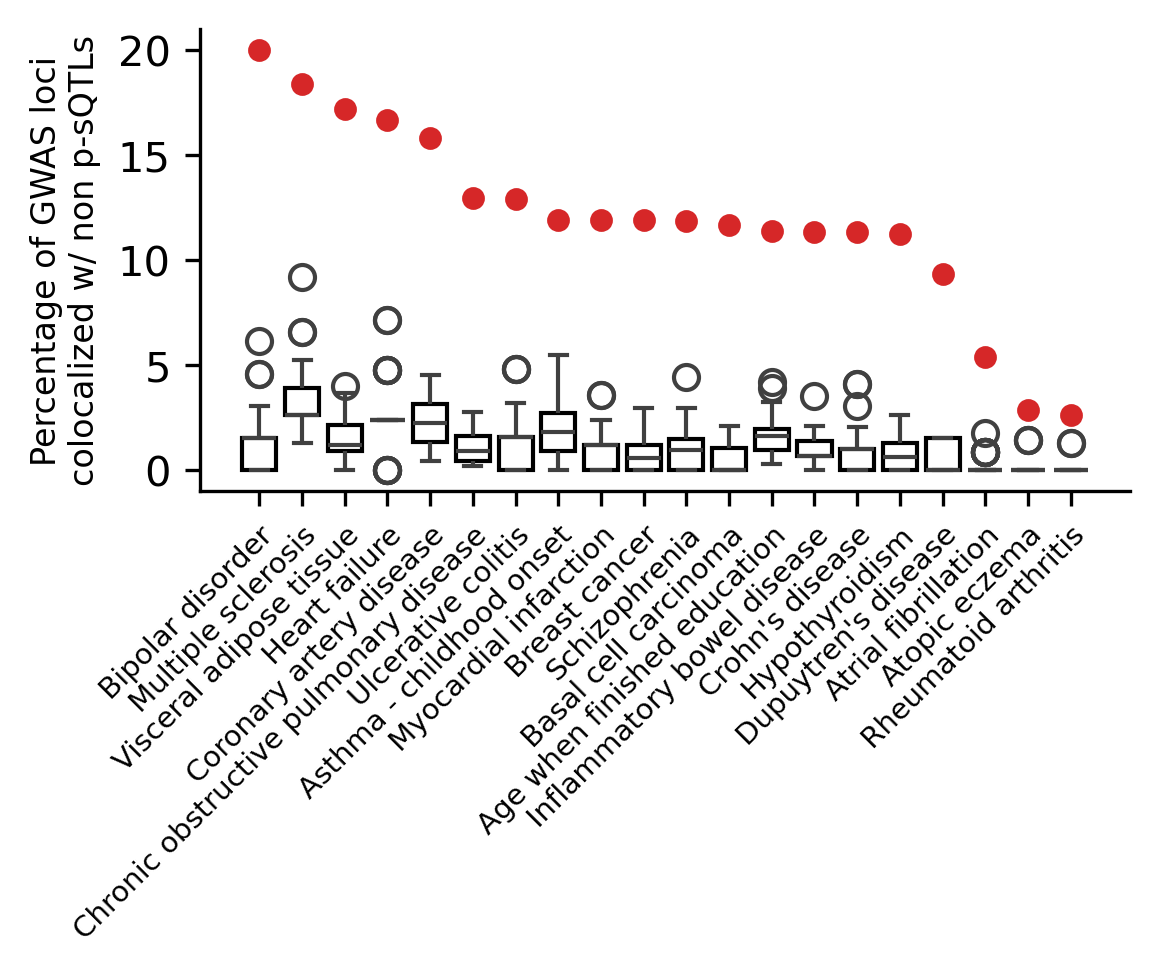

In [37]:
fig, ax = plt.subplots(figsize=(4, 2), dpi=300)
sns.boxplot(data=gwas_pct_df[ordered_traits], ax=ax, boxprops=dict(facecolor='white', edgecolor='black'))
ax.scatter(range(20), list(100*gwas_pct_all_df.loc[ordered_traits].gwas_pct), c='tab:red', s=20)

xlabels = ['Bipolar disorder', 'Multiple sclerosis', 'Visceral adipose tissue', 'Heart failure', 'Coronary artery disease',
    'Chronic obstructive pulmonary disease','Ulcerative colitis', 'Asthma - childhood onset','Myocardial infarction',
    'Breast cancer', 'Schizophrenia','Basal cell carcinoma',  'Age when finished education',
    'Inflammatory bowel disease', "Crohn's disease", 'Hypothyroidism',  "Dupuytren's disease", 'Atrial fibrillation', 
    'Atopic eczema', 'Rheumatoid arthritis']
    
    
ax.set_xticks(range(20), xlabels, rotation=45, ha='right', rotation_mode='anchor', size=7)
ax.set_ylabel('Percentage of GWAS loci\ncolocalized w/ non p-sQTLs', size=8)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('../code/plots/fig4D_coloc.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4D_coloc.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4D_coloc.svg', dpi=300, bbox_inches='tight')

In [38]:
hyprcoloc_up = hyprcoloc.loc[(hyprcoloc.UP_colocs) & hyprcoloc.gwas_colocs ]
hyprcoloc_up.loc[hyprcoloc_up.gwas_trait == 'IMSGC2019'].groupby('tissue').tissue.value_counts()

gwas_pct_list = []
gwas_pct_all_list = []
trait_list = []
for trait, df in hyprcoloc_up.groupby('gwas_trait'): #.loc[nom_df.itype != 'PR'].groupby('gwas_trait'):
    gwas_pct = pd.DataFrame(
        100*df.groupby(['tissue']).tissue.value_counts()/(leadSNPs.loc[leadSNPs.gwas_trait == trait].shape[0])
    )
    gwas_pct.columns = [trait]
    gwas_pct_list.append(gwas_pct)
    
    gwas_pct_all = len(df.gwas_loci.unique())/(leadSNPs.loc[leadSNPs.gwas_trait == trait].shape[0])
    gwas_pct_all_list.append(gwas_pct_all)
    
    trait_list.append(trait)

gwas_pct_df = pd.concat(gwas_pct_list, axis=1).fillna(0)
gwas_pct_all_df = pd.DataFrame()
gwas_pct_all_df['trait'] = trait_list
gwas_pct_all_df['gwas_pct'] = gwas_pct_all_list

ordered_traits = list(gwas_pct_all_df.sort_values('gwas_pct', ascending=False).trait)

gwas_pct_all_df.index = gwas_pct_all_df.trait
# gwas_pct_all_df.loc[ordered_traits]

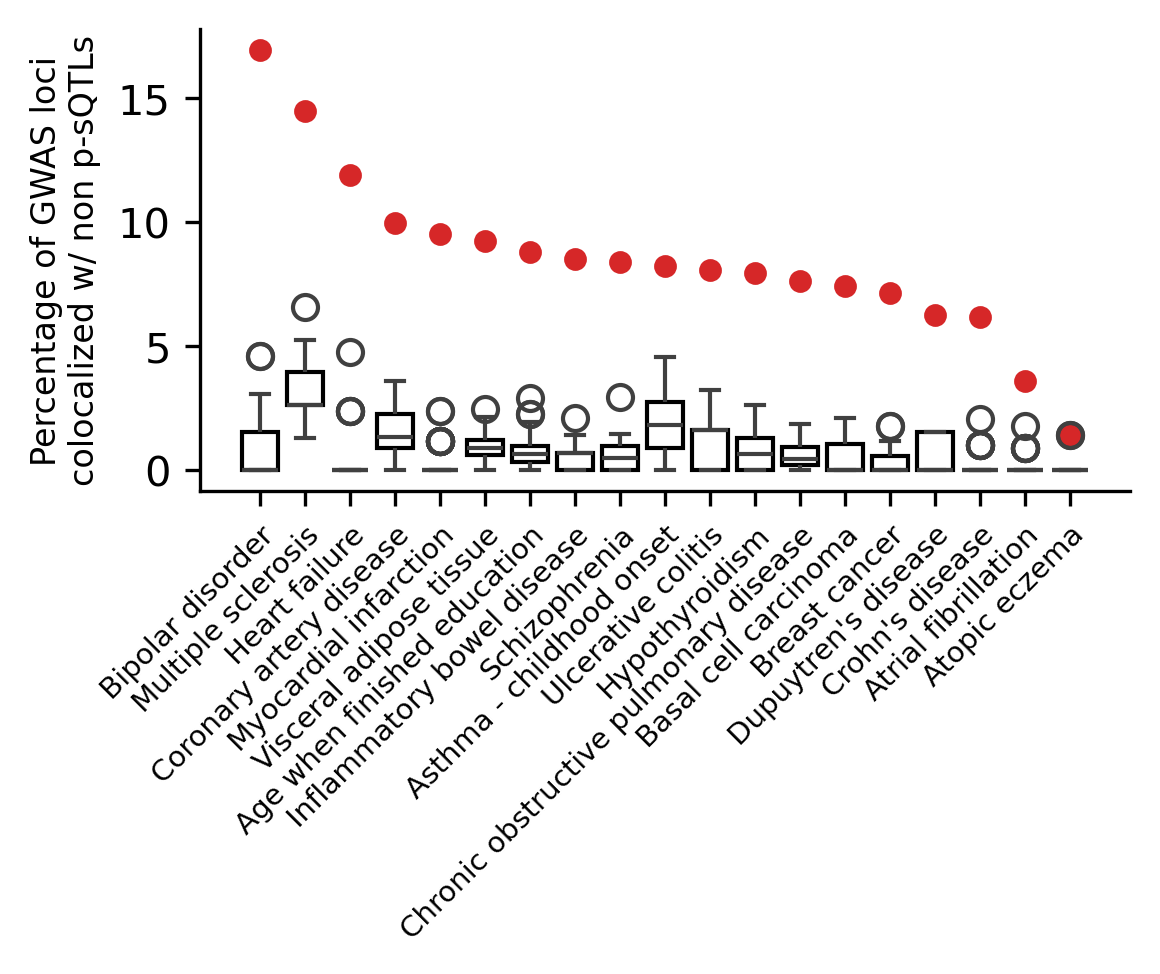

In [40]:
fig, ax = plt.subplots(figsize=(4, 2), dpi=300)
sns.boxplot(data=gwas_pct_df[ordered_traits], ax=ax, boxprops=dict(facecolor='white', edgecolor='black'))
ax.scatter(range(19), list(100*gwas_pct_all_df.loc[ordered_traits].gwas_pct), c='tab:red', s=20)

xlabels = ['Bipolar disorder', 'Multiple sclerosis', 'Heart failure', 'Coronary artery disease', 'Myocardial infarction',
           'Visceral adipose tissue', 'Age when finished education', 'Inflammatory bowel disease', 'Schizophrenia',
           'Asthma - childhood onset', 'Ulcerative colitis', 'Hypothyroidism', 'Chronic obstructive pulmonary disease',
           'Basal cell carcinoma', 'Breast cancer', "Dupuytren's disease",  "Crohn's disease", 'Atrial fibrillation', 
    'Atopic eczema']
    
    
ax.set_xticks(range(19), xlabels, rotation=45, ha='right', rotation_mode='anchor', size=7)
ax.set_ylabel('Percentage of GWAS loci\ncolocalized w/ non p-sQTLs', size=8)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('../code/plots/fig4D2_coloc.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4D2_coloc.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4D2_coloc.svg', dpi=300, bbox_inches='tight')

In [81]:
best_df = nom_df.loc[(nom_df.distance <= 1000) & (nom_df.itype == 'UP') & (((nom_df.sQTL_beta >= 0.02) & (nom_df.eQTL_beta <= -0.02)) | ((nom_df.sQTL_beta <= -0.1) & (nom_df.eQTL_beta >= 0.1)))]
best_df2 = nom_df.loc[(nom_df.distance <= 1000) & (nom_df.itype == 'PR') & (((nom_df.sQTL_beta >= 0.02) & (nom_df.eQTL_beta >= 0.02)) | ((nom_df.sQTL_beta <= -0.1) & (nom_df.eQTL_beta <= -0.1)))]
best_df.loc[best_df.gene == 'ENSG00000100412']

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
1806,chr22:41515917:41517296:clu_32769_+:UP:chr22_4...,ENSG00000100412,chr22_41517840_A_G_b38,544,544,0.396753,0.000005,-0.108433,0.085743,clu_32769_+,UP,Cells-EBV-transformedlymphocytes,0.017089,chr22,41515917,41517296,GCST007800,chr22_41459919_N_N_GCST007800


In [87]:
best_df.loc[best_df.tissue.apply(lambda x: 'Brain' in x)]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
615,chr13:27429389:27429869:clu_23700_+:UP:chr13_2...,ENSG00000122034,chr13_27428587_C_T_b38,802,802,0.336260,7.187190e-05,-0.215238,1.002350e-04,clu_23700_+,UP,Brain-Hippocampus,0.066396,chr13,27429389,27429869,Visceral_adipose_tissue_measurement,chr13_27438390_N_N_Visceral_adipose_tissue_mea...
1083,chr17:44176940:44177608:clu_28859_+:UP:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,27,27,-0.622274,2.053880e-11,0.246418,6.448610e-08,clu_28859_+,UP,Brain-CerebellarHemisphere,0.504950,chr17,44176940,44177608,bipolar_disorder,chr17_44114525_N_N_bipolar_disorder
1085,chr17:44176940:44177608:clu_29318_+:UP:chr17_4...,ENSG00000161664,chr17_44176913_A_G_b38,27,27,-0.594865,3.708880e-13,0.209502,2.003820e-05,clu_29318_+,UP,Brain-Cerebellum,0.538969,chr17,44176940,44177608,bipolar_disorder,chr17_44114525_N_N_bipolar_disorder
1297,chr18:12817365:12818943:clu_31142_-:UP:chr18_1...,ENSG00000175354,chr18_12818923_G_A_b38,0,20,0.524144,9.812370e-05,-0.025514,7.504390e-01,clu_31142_-,UP,Brain-CerebellarHemisphere,0.077696,chr18,12817365,12818943,GCST004132,chr18_12818923_N_N_GCST004132


In [104]:
44176913 - 44114525

62388

In [86]:
best_df.loc[best_df.tissue.apply(lambda x: 'EBV' in x)]

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
341,chr12:57694926:57695542:clu_19636_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,88,88,-0.620360,2.068250e-12,0.156767,0.002946,clu_19636_+,UP,Cells-EBV-transformedlymphocytes,0.017566,chr12,57694926,57695542,IMSGC2019,chr12_57713053_N_N_IMSGC2019
343,chr12:57695677:57695779:clu_19636_+:UP:chr12_5...,ENSG00000135506,chr12_57695630_A_T_b38,47,47,-0.623275,3.120300e-13,0.156767,0.002946,clu_19636_+,UP,Cells-EBV-transformedlymphocytes,0.015642,chr12,57695677,57695779,IMSGC2019,chr12_57713053_N_N_IMSGC2019
1806,chr22:41515917:41517296:clu_32769_+:UP:chr22_4...,ENSG00000100412,chr22_41517840_A_G_b38,544,544,0.396753,5.346210e-06,-0.108433,0.085743,clu_32769_+,UP,Cells-EBV-transformedlymphocytes,0.017089,chr22,41515917,41517296,GCST007800,chr22_41459919_N_N_GCST007800


In [85]:
best_df.loc[best_df.gwas_trait == 'basal_cell_carcinoma']

,intron,gene,var_id,distance,distance_abs,sQTL_beta,sQTL_pval,eQTL_beta,eQTL_pval,cluster,itype,tissue,PSI,chrom,start,end,gwas_trait,gwas_loci
1010,chr16:90032924:90036380:clu_29283_+:UP:chr16_9...,ENSG00000141013,chr16_90036709_G_A_b38,329,329,0.186739,6.335790e-08,-0.544761,3.924830e-56,clu_29283_+,UP,Muscle-Skeletal,0.063809,chr16,90032924,90036380,basal_cell_carcinoma,chr16_90036709_N_N_basal_cell_carcinoma
1011,chr16:90035879:90036380:clu_29283_+:UP:chr16_9...,ENSG00000141013,chr16_90036709_G_A_b38,329,329,0.203948,1.866750e-06,-0.544761,3.924830e-56,clu_29283_+,UP,Muscle-Skeletal,0.052717,chr16,90035879,90036380,basal_cell_carcinoma,chr16_90036709_N_N_basal_cell_carcinoma


In [88]:
input_bed = '/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/QTLs/QTLTools/chRNA.Splicing/OnlyFirstReps.PSI.bed.gz'
output = '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/pheno/GEUVADIS/naRNA.PSI.bed.gz'

import gzip
with gzip.open(input_bed, 'rb') as fh:
    with gzip.open(output, 'wb') as fh2:
        x = fh.readline()#.decode()
        fh2.write(x)
        for line in fh:
            row = line.decode().rstrip().split('\t')
            bed = row[:6]
            y = [str(float(z)*100) if z != 'NA' else 'NA' for z in row[6:]]
            out_line = '\t'.join(bed + y) + '\n'
            fh2.write(out_line.encode())
            
            

In [90]:
input_bed = '/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/QTLs/QTLTools/polyA.Splicing/OnlyFirstReps.PSI.bed.gz'
output = '/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/pheno/GEUVADIS/steady_state_RNA.PSI.bed.gz'

import gzip
with gzip.open(input_bed, 'rb') as fh:
    with gzip.open(output, 'wb') as fh2:
        x = fh.readline()#.decode()
        fh2.write(x)
        for line in fh:
            row = line.decode().rstrip().split('\t')
            bed = row[:6]
            y = [str(float(z)*100) if z != 'NA' else 'NA' for z in row[6:]]
            out_line = '\t'.join(bed + y) + '\n'
            fh2.write(out_line.encode())
            
            

In [91]:
import os 

In [102]:
naRNA_samples = os.listdir('/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/bigwigs/chRNA.Expression.Splicing')
naRNA_samples = sorted(set([x.split('.')[0] for x in naRNA_samples if 'NA18855' not in x]))
naRNA_df = pd.DataFrame()
naRNA_df['sample'] = naRNA_samples
bw_path = '/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/bigwigs'
naRNA_df['bigwigPath'] = [f'{bw_path}/chRNA.Expression.Splicing/{sample}.1.bw' for sample in naRNA_samples]
naRNA_df['Group_label'] = ['naRNA']*len(naRNA_samples)
naRNA_df['strand'] = ['.']*len(naRNA_samples)
naRNA_df.to_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_sashimi_plots/input/GEUVADIS.bigwig_list.naRNA.tsv', sep='\t', header=True, index=False)

In [103]:
naRNA_samples = os.listdir('/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/bigwigs/Expression.Splicing')
naRNA_samples = sorted(set([x.split('.')[0] for x in naRNA_samples]))
naRNA_df = pd.DataFrame()
naRNA_df['sample'] = naRNA_samples
bw_path = '/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/bigwigs'
naRNA_df['bigwigPath'] = [f'{bw_path}/Expression.Splicing/{sample}.1.bw' for sample in naRNA_samples]
naRNA_df['Group_label'] = ['polyA']*len(naRNA_samples)
naRNA_df['strand'] = ['.']*len(naRNA_samples)
naRNA_df.to_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_sashimi_plots/input/GEUVADIS.bigwig_list.polyA.tsv', sep='\t', header=True, index=False)

In [106]:
hyprcoloc.to_csv('../code/results/coloc/hyprcoloc_results/tables/annotated_results.tsv.gz', 
                 sep='\t', header=True, index=False)

In [109]:
nom_df.to_csv('../code/results/coloc/hyprcoloc_results/tables/up_results.tsv.gz', 
                 sep='\t', header=True, index=False)

In [108]:
hyprcoloc

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,tissue
0,1,Adipose-Subcutaneous.leafcutter_N_N_chr10:1009...,0.5347,0.9546,chr10_100983006_C_A_b38,0.2561,NaN,Visceral_adipose_tissue_measurement,False,False,True,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,Adipose-Subcutaneous
1,2,Adipose-Subcutaneous.leafcutter_N_N_chr10:1004...,0.6701,0.9998,chr10_100498682_C_T_b38,0.5757,NaN,Visceral_adipose_tissue_measurement,False,True,False,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,Adipose-Subcutaneous
2,5,Adipose-Subcutaneous.leafcutter_N_N_chr10:1010...,0.9924,1.0000,chr10_101044468_C_A_b38,0.3763,NaN,Visceral_adipose_tissue_measurement,False,True,False,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,Adipose-Subcutaneous
3,1,Adipose-Visceral_Omentum.leafcutter_N_N_chr10:...,0.5905,0.8163,chr10_100985305_G_T_b38,0.4630,NaN,Visceral_adipose_tissue_measurement,False,False,True,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,Adipose-Visceral_Omentum
4,2,Adipose-Visceral_Omentum.leafcutter_N_N_chr10:...,0.6629,0.9846,chr10_100501996_A_G_b38,0.3076,NaN,Visceral_adipose_tissue_measurement,False,True,False,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,Adipose-Visceral_Omentum
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136901,2,Thyroid.leafcutter_N_N_chr9:99040556:99040703:...,0.9038,0.9484,chr9_99056648_T_G_b38,0.2494,NaN,GCST007800,False,True,False,True,False,chr9_99227424_N_N_GCST007800,Thyroid
136902,3,Adipose-Visceral_Omentum.leafcutter_N_N_chr9:9...,0.7686,0.8076,chr9_99244656_T_C_b38,0.2685,NaN,Atopic_eczema,False,False,False,True,False,chr9_99568999_N_N_Atopic_eczema,Adipose-Visceral_Omentum
136903,1,Cells-Culturedfibroblasts.expression_N_N_ENSG0...,0.4156,0.5498,chr9_100068205_A_G_b38,0.2910,NaN,Atopic_eczema,False,False,True,False,False,chr9_99568999_N_N_Atopic_eczema,NaN
136904,1,Cells-EBV-transformedlymphocytes.expression_N_...,0.3886,0.6330,chr9_99179442_C_T_b38,0.1272,NaN,Atopic_eczema,False,False,True,False,False,chr9_99568999_N_N_Atopic_eczema,NaN


In [26]:
hyprcoloc_up = hyprcoloc.loc[(hyprcoloc.UP_colocs) & hyprcoloc.gwas_colocs ]
hyprcoloc_up.loc[hyprcoloc_up.gwas_trait == 'IMSGC2019'].groupby('tissue').tissue.value_counts()

gwas_pct_list = []
gwas_pct_all_list = []
trait_list = []
for trait, df in hyprcoloc_up.groupby('gwas_trait'): #.loc[nom_df.itype != 'PR'].groupby('gwas_trait'):
    gwas_pct = pd.DataFrame(
        df.groupby(['tissue']).tissue.value_counts()
    )
    gwas_pct.columns = [trait]
    gwas_pct_list.append(gwas_pct)
    
    gwas_pct_all = len(df.gwas_loci.unique())
    gwas_pct_all_list.append(gwas_pct_all)
    
    trait_list.append(trait)

gwas_pct_df = pd.concat(gwas_pct_list, axis=1).fillna(0)
gwas_pct_all_df = pd.DataFrame()
gwas_pct_all_df['trait'] = trait_list
gwas_pct_all_df['gwas_pct'] = gwas_pct_all_list

ordered_traits = list(gwas_pct_all_df.sort_values('gwas_pct', ascending=False).trait)

gwas_pct_all_df.index = gwas_pct_all_df.trait
gwas_pct_all_df.loc[ordered_traits]

,trait,gwas_pct
trait,,
Chronic_obstructive_pulmonary_disease,Chronic_obstructive_pulmonary_disease,33
Visceral_adipose_tissue_measurement,Visceral_adipose_tissue_measurement,30
age_when_finished_full-time_education,age_when_finished_full-time_education,27
coronary_artery_disease,coronary_artery_disease,22
schizophrenia,schizophrenia,17
Hypothyroidism,Hypothyroidism,12
GCST004131,GCST004131,12
GCST004988,GCST004988,12
IMSGC2019,IMSGC2019,11


In [28]:
gwas_pct_all_df

,trait,gwas_pct
trait,,
Atopic_eczema,Atopic_eczema,1
Chronic_obstructive_pulmonary_disease,Chronic_obstructive_pulmonary_disease,33
Dupuytrens_disease,Dupuytrens_disease,4
GCST004131,GCST004131,12
GCST004132,GCST004132,6
GCST004133,GCST004133,5
GCST004988,GCST004988,12
GCST007800,GCST007800,9
Hypothyroidism,Hypothyroidism,12
